In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# CELL 1: Setup and Environment

print("--- Installing packages... ---")
%pip install pandas geopandas rasterio shapely fiona pyproj rapidfuzz xarray netCDF4 dask matplotlib seaborn -q

from google.colab import drive
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

drive.mount('/content/drive', force_remount=True)
%cd "/content/drive/MyDrive/IndiaProject_Colab"

print("\n--- Loading Functions ---")
%run 00_Functions_and_Setup.ipynb
print("Setup complete.")

--- Installing packages... ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.6 MB/s eta 0:00:00
Mounted at /content/drive
/content/drive/MyDrive/IndiaProject_Colab

--- Loading Functions ---
Setup complete.


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# CELL 2: Load Hierarchical Results & Define Cropping Fraction

# --- 1. Load Data ---
# Note: We now target the HIERARCHICAL file generated by the updated Notebook 02
FINAL_RESULTS_FILE = "results/FINAL_HIERARCHICAL_metrics.parquet"
YLD_FILE = "data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv"
DISTRICTS_GEO_FILE = "data/processed/districts_joined.gpkg"

try:
    results_df = pd.read_parquet(FINAL_RESULTS_FILE)
    yld = pd.read_csv(YLD_FILE)
    districts_gdf = gpd.read_file(DISTRICTS_GEO_FILE)

    print(f"[✓] Loaded Results: {len(results_df)} district-models.")
    print(f"    Columns available: {results_df.columns.tolist()}")

except FileNotFoundError as e:
    raise SystemExit(f"Missing File: {e}")

# --- 2. Define The Filter Metric: Cropping Fraction ---
# (Replaces the old 'Production Density' logic)
def get_cropping_fraction(crop_name):
    """
    Calculates the fraction of district area dedicated to the crop.
    Metric: (Average Harvested Area) / (District Shapefile Area)
    """
    # 1. Get Average Harvested Area (ha)
    crop_data = yld[(yld['crop'] == crop_name) & (yld['yield_kg_per_ha'] > 0)].copy()
    avg_area = crop_data.groupby('Dist Code')['total_area_1000ha'].mean().reset_index()
    avg_area['harvested_ha'] = avg_area['total_area_1000ha'] * 1000

    # 2. Get District Total Area (ha) - Using Equal Area Projection
    dist_proj = districts_gdf.to_crs(epsg=6933)
    dist_areas = dist_proj[['Dist Code', 'geometry']].copy()
    dist_areas['district_total_ha'] = dist_proj.geometry.area / 10000

    # 3. Merge
    merged = avg_area.merge(dist_areas, on='Dist Code', how='inner')
    merged['cropping_fraction'] = merged['harvested_ha'] / merged['district_total_ha']

    # Clip to 1.0 to handle data noise
    merged['cropping_fraction'] = merged['cropping_fraction'].clip(upper=1.0)

    return merged[['Dist Code', 'cropping_fraction']]

print("[✓] Helper function 'get_cropping_fraction' defined.")

[✓] Loaded Results: 2504 district-models.
    Columns available: ['Dist Code', 'state', 'district', 'n_years', 'R2_1_Trend', 'R2_2_Climate', 'R2_3_Irrig', 'R2_4_Full', 'Mq_Climate', 'Mq_Irrig', 'Mq_SIF', 'R2_partial', 'R2_cv', 'beta_std__Year', 'beta_std__sm_season_mean', 'beta_std__tmax_season_mean', 'beta_std__irrigated_pct', 'beta_std__csif_season_mean', 'year_shift', 'crop']
[✓] Helper function 'get_cropping_fraction' defined.


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# CELL 3: Table 1 - Marginal "Value Add" Analysis (Partial R²)

print("--- Table 1: Marginal R² Gain (Value Added vs. Previous Step) ---")
print("    Base: Trend")
print("    Columns show how much R² increases when that variable is added.")

# 1. Calculate the Marginal Gains (Deltas)
# We subtract the previous step's R2 from the current step
results_df['Gain_Climate'] = results_df['R2_2_Climate'] - results_df['R2_1_Trend']
results_df['Gain_Irrig']   = results_df['R2_3_Irrig']   - results_df['R2_2_Climate']
results_df['Gain_SIF']     = results_df['R2_4_Full']    - results_df['R2_3_Irrig']

# 2. Calculate "Total Partial R2" (Everything except Trend)
# This represents the total explanatory power of Environmental/Biotic factors
results_df['Total_Partial_R2'] = results_df['R2_4_Full'] - results_df['R2_1_Trend']

# 3. Group and Aggregate
evolution_table = results_df.groupby(['crop', 'year_shift'])[[
    'R2_1_Trend',       # The Baseline
    'Gain_Climate',     # Value Add of Climate
    'Gain_Irrig',       # Value Add of Irrigation
    'Gain_SIF',         # Value Add of SIF
    'Total_Partial_R2'  # Total Value Add (Sum of Gains)
]].mean()

# 4. Rename columns for clarity
evolution_table.columns = [
    'Base Trend R²',
    '+ Climate',
    '+ Irrigation',
    '+ SIF',
    'Total Partial R²'
]

# 5. Display with Heatmap
# We color the "Gains" to see where the signal is coming from
pd.set_option('display.max_rows', None)
display(evolution_table.style.background_gradient(cmap='Greens', axis=0).format("{:.3f}"))

--- Table 1: Marginal R² Gain (Value Added vs. Previous Step) ---
    Base: Trend
    Columns show how much R² increases when that variable is added.


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# REPLACEMENT CELL: Table 1 (Styled with Red Winners & Crop Separators)

import pandas as pd
import numpy as np

print("--- Table 1: Marginal R² Gain (with Winners Highlighted) ---")
print("    Red Box = Best Shift for that specific variable & crop.")

# --- 1. Prepare Data (Same logic as before) ---
# Calculate Gains
results_df['Gain_Climate'] = results_df['R2_2_Climate'] - results_df['R2_1_Trend']
results_df['Gain_Irrig']   = results_df['R2_3_Irrig']   - results_df['R2_2_Climate']
results_df['Gain_SIF']     = results_df['R2_4_Full']    - results_df['R2_3_Irrig']
results_df['Total_Partial_R2'] = results_df['R2_4_Full'] - results_df['R2_1_Trend']

# Group Mean
evolution_table = results_df.groupby(['crop', 'year_shift'])[[
    'R2_1_Trend', 'Gain_Climate', 'Gain_Irrig', 'Gain_SIF', 'Total_Partial_R2'
]].mean()

# Rename
evolution_table.columns = [
    'Base Trend R²', '+ Climate', '+ Irrigation', '+ SIF', 'Total Partial R²'
]

# --- 2. Define Custom Styling Function ---
def highlight_winners_and_separators(df):
    # Create a DataFrame of empty strings with same shape as data
    styles = pd.DataFrame('', index=df.index, columns=df.columns)

    # A. Highlight Winners (Red Border)
    # We group by 'crop' (level 0 index) and find the max for each column
    max_vals = df.groupby(level=0).transform('max')

    # Iterate to apply border where value == max_val for that crop
    for col in df.columns:
        # Mask for winners
        is_winner = df[col] == max_vals[col]

        # Apply style to winners
        # Note: We use a loop because vectorizing string assignment on MultiIndex is tricky
        for idx in df.index:
            if is_winner.loc[idx]:
                styles.loc[idx, col] += 'border: 2px solid red; font-weight: bold; '

    # B. Crop Separators (Thick Bottom Border)
    # Identify the last row of each crop group (where year_shift == 1)
    # We iterate through the index
    last_row_indices = [idx for idx in df.index if idx[1] == 1]

    for idx in last_row_indices:
        # Don't underline the very last row of the whole table
        if idx != df.index[-1]:
            for col in df.columns:
                styles.loc[idx, col] += 'border-bottom: 3px solid #444444; '

    return styles

# --- 3. Display ---
# We chain the styles: First the Green Gradient, then our Custom Function
styled_table = (evolution_table.style
                .background_gradient(cmap='Greens', axis=0)
                .format("{:.3f}")
                .apply(highlight_winners_and_separators, axis=None) # Axis=None applies to whole table
               )

display(styled_table)

--- Table 1: Marginal R² Gain (with Winners Highlighted) ---
    Red Box = Best Shift for that specific variable & crop.


--- Visualizing Model Composition (Top 50 Reliable Districts) ---


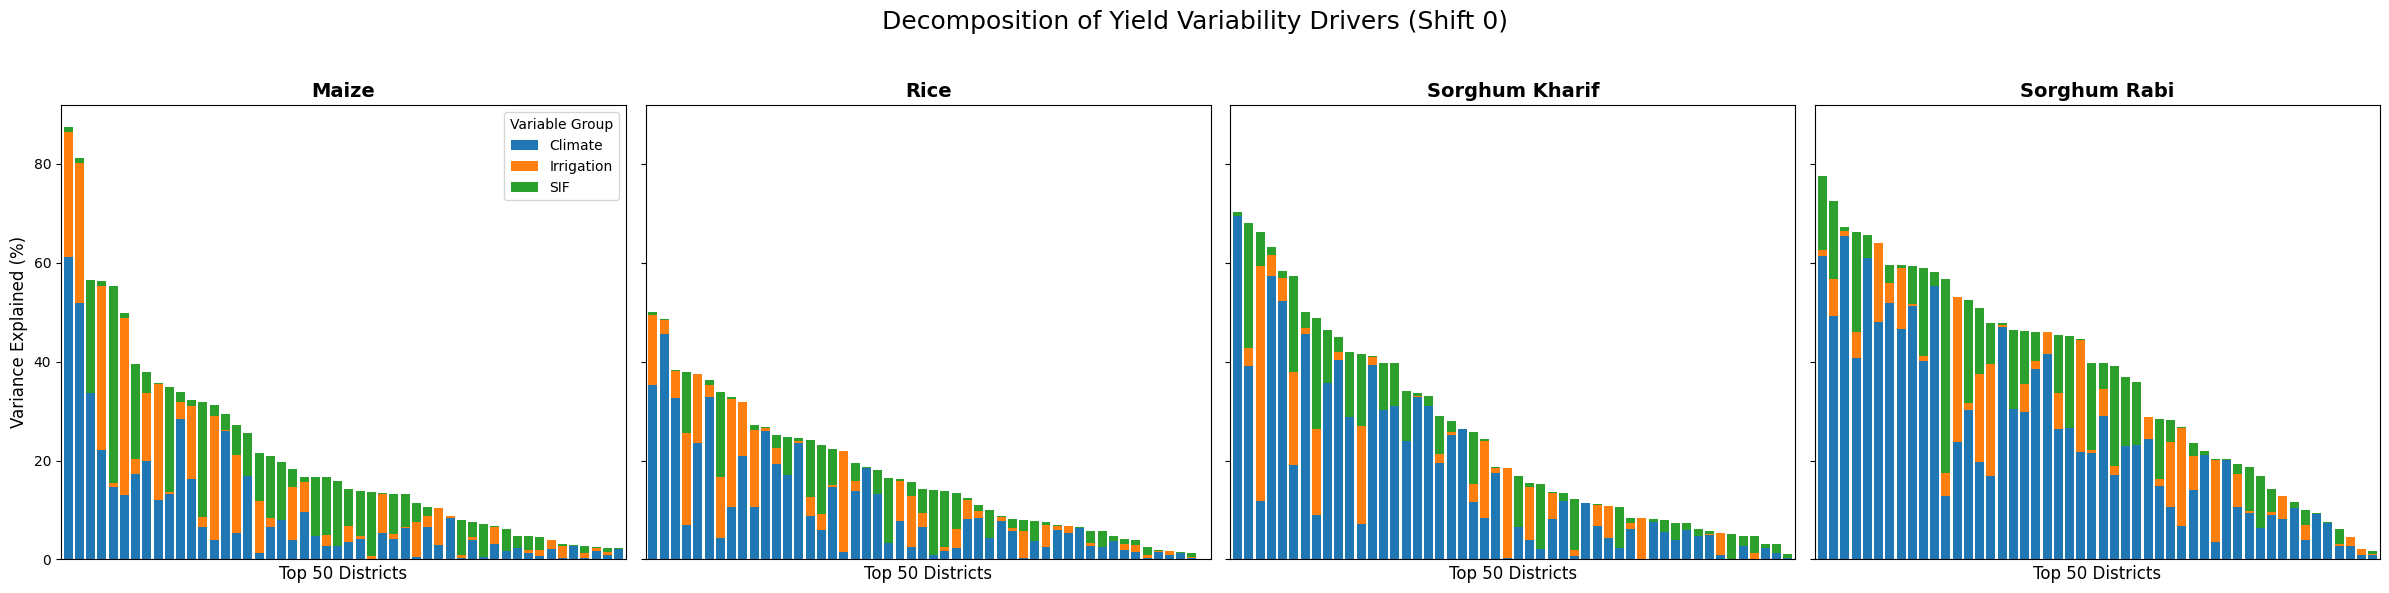


Average Contribution in Top 50 Districts (% Variance Explained):


,Climate %,Irrigation %,SIF %
maize,9.36,5.99,6.34
rice,9.72,4.03,3.34
sorghum_kharif,16.35,4.09,4.90
sorghum_rabi,24.93,5.11,7.21


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# REPLACEMENT CELL: Decomposition of Predictive Power (Stacked Bar Chart)

import matplotlib.pyplot as plt
import pandas as pd

print("--- Visualizing Model Composition (Top 50 Reliable Districts) ---")

# --- Configuration ---
# We use Shift 0 (Planting Year) for ALL crops now
target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Colors: Blue (Nature), Orange (Infrastructure), Green (Biotic)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Filter Data for this Crop/Shift
    df = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()

    # 2. Filter for Top 50 Districts by Model Reliability (R2_cv)
    # We want to see the composition of the *working* models
    top_districts = df.nlargest(50, 'R2_cv')

    # 3. Prepare Data for Stacked Bar (Marginal Gains)
    plot_data = top_districts[['Mq_Climate', 'Mq_Irrig', 'Mq_SIF']].copy() * 100
    plot_data.columns = ['Climate', 'Irrigation', 'SIF']

    # Sort by Total Explanatory Power (for visual organization)
    plot_data['Total'] = plot_data.sum(axis=1)
    plot_data = plot_data.sort_values('Total', ascending=False).drop(columns='Total')

    # 4. Plot
    plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

    # Styling
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Top 50 Districts", fontsize=12)
    ax.set_xticks([]) # Hide x-axis labels (too cluttered)

    if i == 0:
        ax.set_ylabel("Variance Explained (%)", fontsize=12)
        ax.legend(title="Variable Group", loc='upper right')
    else:
        ax.get_legend().remove()

plt.suptitle("Decomposition of Yield Variability Drivers (Shift 0)", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Quantitative Check ---
print("\nAverage Contribution in Top 50 Districts (% Variance Explained):")
summary_stats = []
for crop in crops:
    df = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].nlargest(50, 'R2_cv')
    means = df[['Mq_Climate', 'Mq_Irrig', 'Mq_SIF']].mean() * 100
    means.name = crop
    summary_stats.append(means)

summary_df = pd.DataFrame(summary_stats)
summary_df.columns = ['Climate %', 'Irrigation %', 'SIF %']
display(summary_df.round(2))

--- Visualizing Model Composition (Top 50 Predictable Districts) ---
    Selection Criteria: Highest Total Partial R² (Full Model - Trend)


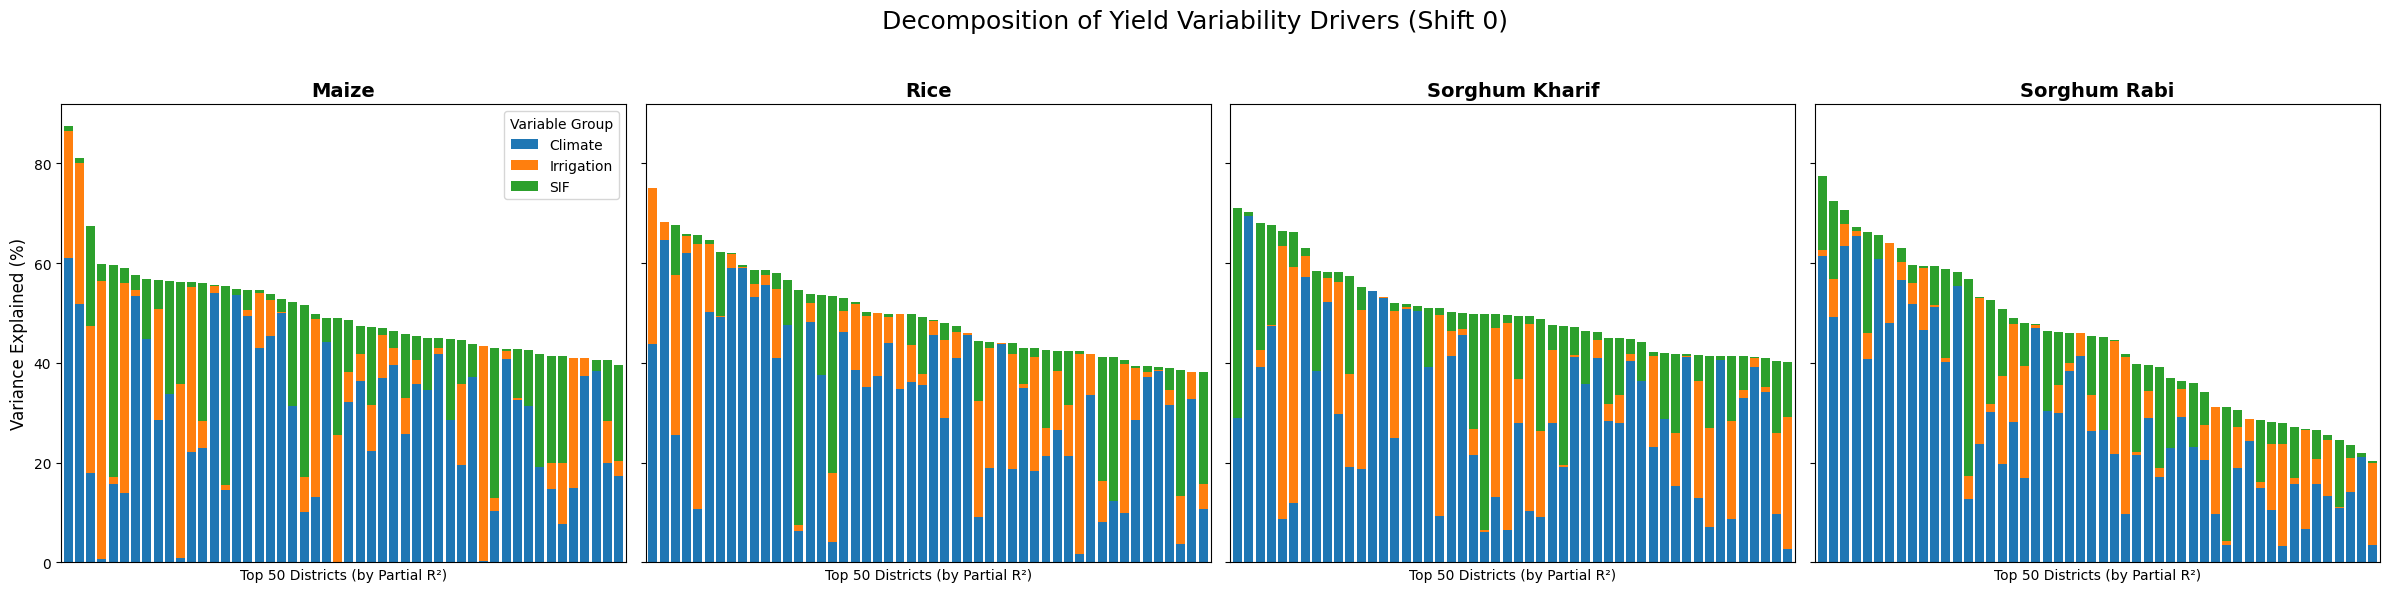


Average Contribution in Top 50 Districts (% Variance Explained):


,Climate %,Irrigation %,SIF %
maize,29.04,10.76,10.94
rice,32.96,10.38,6.69
sorghum_kharif,29.59,11.55,9.33
sorghum_rabi,28.88,7.54,8.11


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# REPLACEMENT CELL: Decomposition of Predictive Power (Sorted by Partial R2)

import matplotlib.pyplot as plt
import pandas as pd

print("--- Visualizing Model Composition (Top 50 Predictable Districts) ---")
print("    Selection Criteria: Highest Total Partial R² (Full Model - Trend)")

# --- Configuration ---
target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Filter Data (Shift 0)
    df = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()

    # 2. Calculate Sorting Metric (Total Partial R2)
    df['Total_Partial_R2'] = df['R2_4_Full'] - df['R2_1_Trend']

    # 3. Filter for Top 50 Districts by Partial R2
    top_districts = df.nlargest(50, 'Total_Partial_R2')

    # 4. Prepare Data for Stacked Bar (Marginal Gains)
    plot_data = top_districts[['Mq_Climate', 'Mq_Irrig', 'Mq_SIF']].copy() * 100
    plot_data.columns = ['Climate', 'Irrigation', 'SIF']

    # Sort strictly by the total height of the bar for visual clarity
    plot_data['Total'] = plot_data.sum(axis=1)
    plot_data = plot_data.sort_values('Total', ascending=False).drop(columns='Total')

    # 5. Plot
    plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

    # Styling
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"Top 50 Districts (by Partial R²)", fontsize=10)
    ax.set_xticks([]) # Hide x-axis labels

    if i == 0:
        ax.set_ylabel("Variance Explained (%)", fontsize=12)
        ax.legend(title="Variable Group", loc='upper right')
    else:
        ax.get_legend().remove()

plt.suptitle("Decomposition of Yield Variability Drivers (Shift 0)", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Quantitative Check ---
print("\nAverage Contribution in Top 50 Districts (% Variance Explained):")
summary_stats = []
for crop in crops:
    df = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()
    df['Total_Partial_R2'] = df['R2_4_Full'] - df['R2_1_Trend']

    top_df = df.nlargest(50, 'Total_Partial_R2')
    means = top_df[['Mq_Climate', 'Mq_Irrig', 'Mq_SIF']].mean() * 100
    means.name = crop
    summary_stats.append(means)

summary_df = pd.DataFrame(summary_stats)
summary_df.columns = ['Climate %', 'Irrigation %', 'SIF %']
display(summary_df.round(2))

--- Generating Winning Shift Maps (Final Legend Logic) ---


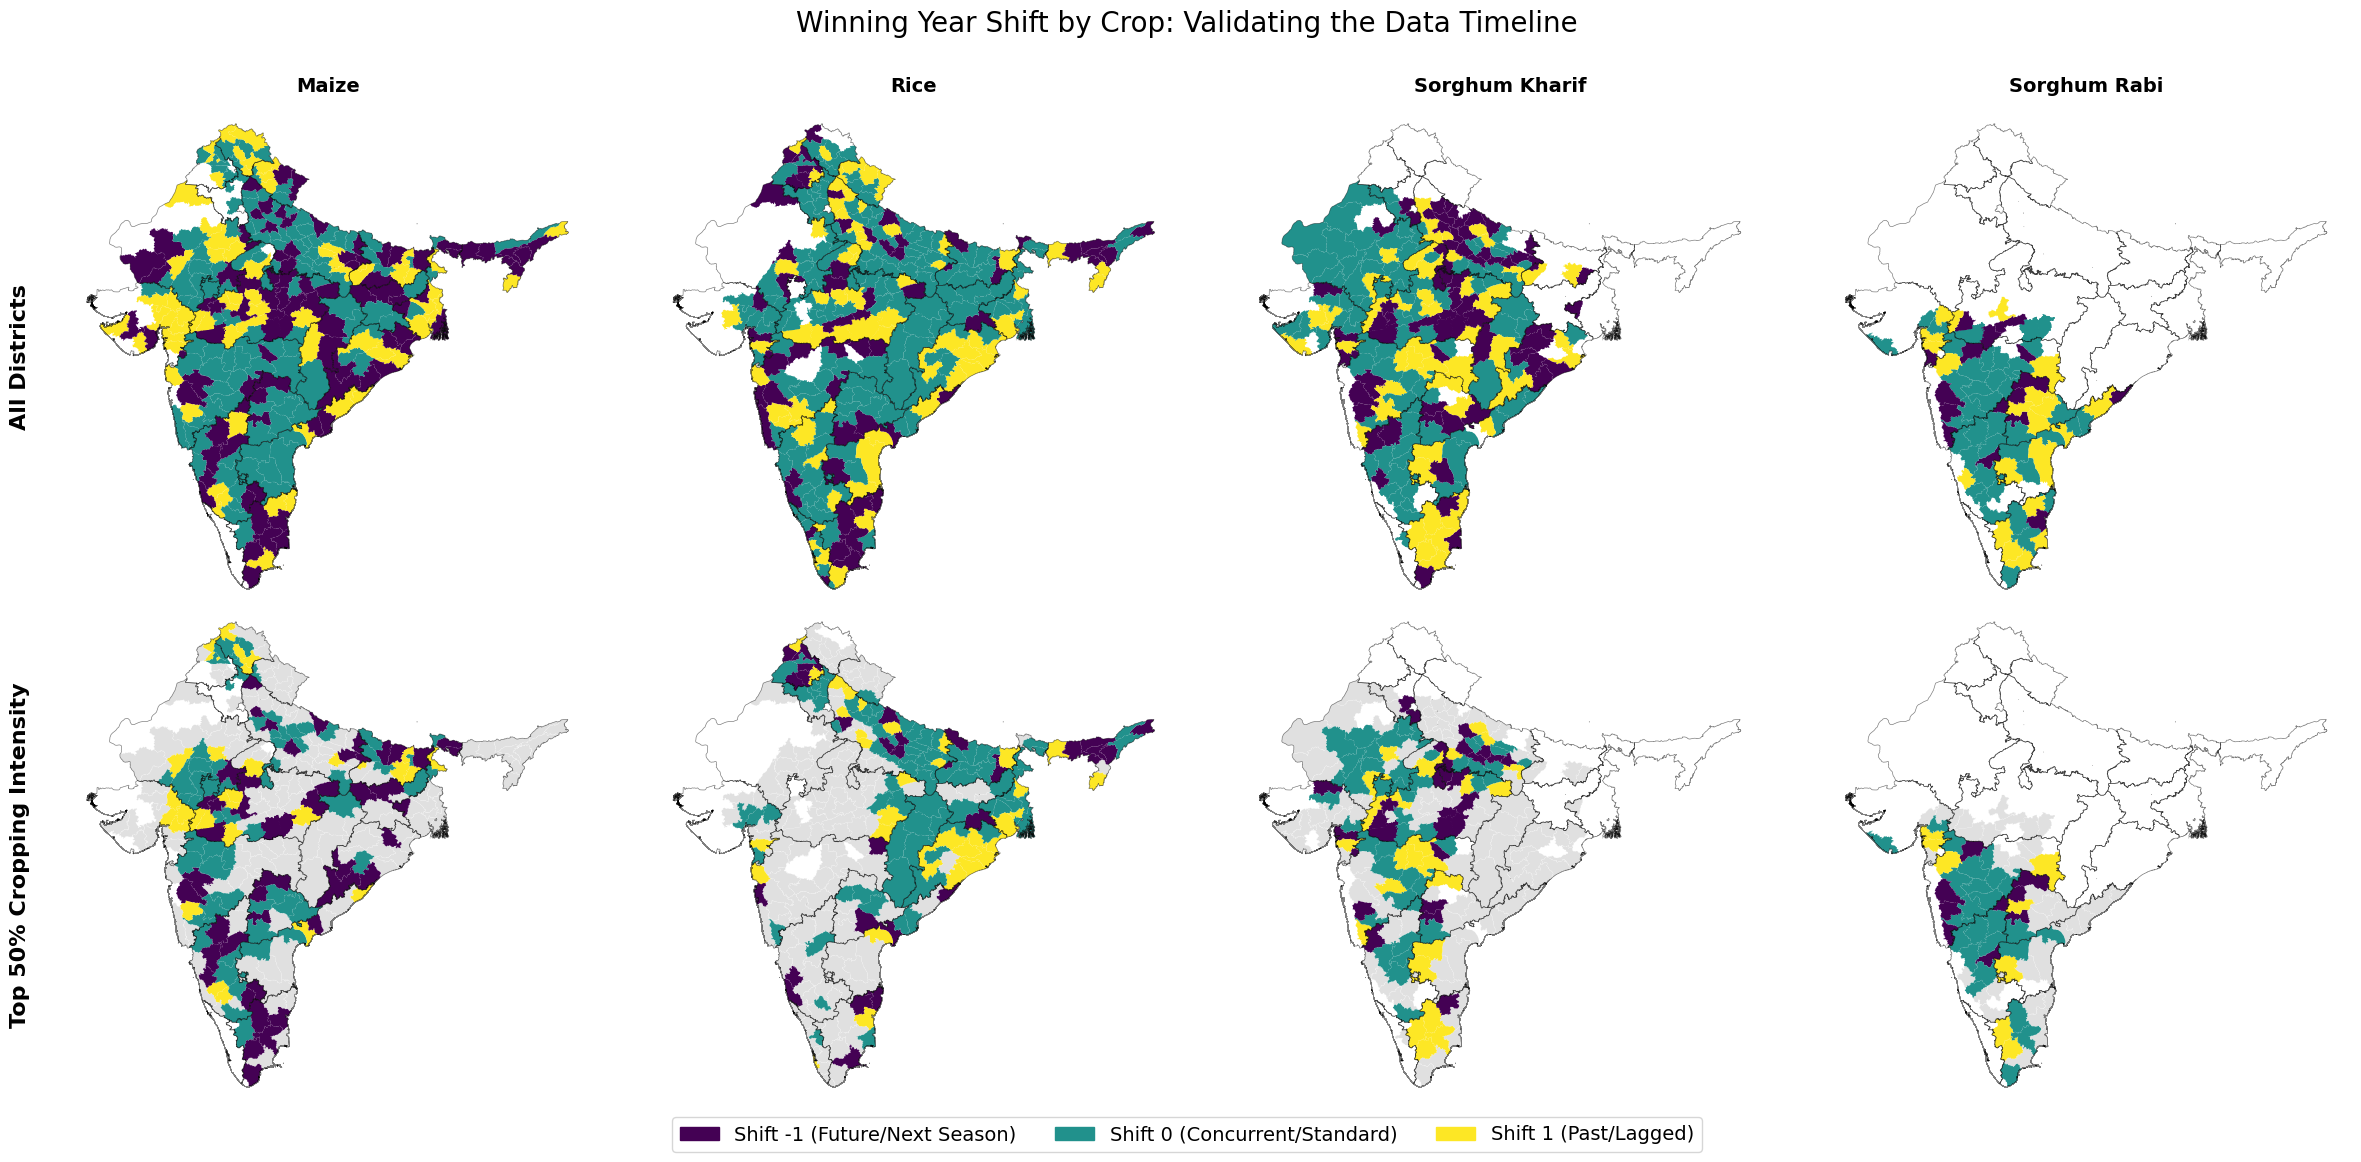

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# RE-RUN CELL: Winning Shift Maps (Updated Legend)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("--- Generating Winning Shift Maps (Final Legend Logic) ---")

# (Data prep remains the same)
results_df['Total_Partial_R2'] = results_df['R2_4_Full'] - results_df['R2_1_Trend']
idx = results_df.groupby(['Dist Code', 'crop'])['Total_Partial_R2'].idxmax()
best_shift_df = results_df.loc[idx].copy()

crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
titles = ["Maize", "Rice", "Sorghum Kharif", "Sorghum Rabi"]

color_map = {
    -1: '#440154', # Purple
     0: '#21918c', # Teal
     1: '#fde725'  # Yellow
}

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
rows = ["All Districts", "Top 50% Cropping Intensity"]

for col_idx, crop in enumerate(crops):
    crop_results = best_shift_df[best_shift_df['crop'] == crop]
    geo_data = districts_gdf.merge(crop_results, on='Dist Code', how='inner')

    # Calculate Intensity
    cf_df = get_cropping_fraction(crop)
    threshold = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')

    # --- ROW 1 ---
    ax1 = axes[0, col_idx]
    geo_data.plot(color=geo_data['year_shift'].map(color_map), ax=ax1)
    state_boundaries_gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax1.set_axis_off()
    ax1.set_title(f"{titles[col_idx]}", fontsize=14, fontweight='bold')

    # --- ROW 2 ---
    ax2 = axes[1, col_idx]
    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    if not bottom_50.empty:
        bottom_50.plot(ax=ax2, color='#e0e0e0', edgecolor='white', linewidth=0.1)
    if not top_50.empty:
        top_50.plot(color=top_50['year_shift'].map(color_map), ax=ax2)

    state_boundaries_gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax2.set_axis_off()

# Row Labels
for r, label in enumerate(rows):
    axes[r, 0].text(-0.1, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va='center', fontsize=16, fontweight='bold')

# --- UPDATED LEGEND ---
legend_patches = [
    mpatches.Patch(color=color_map[-1], label='Shift -1 (Future/Next Season)'),
    mpatches.Patch(color=color_map[0],  label='Shift 0 (Concurrent/Standard)'),
    mpatches.Patch(color=color_map[1],  label='Shift 1 (Past/Lagged)')
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 0.02))

plt.suptitle("Winning Year Shift by Crop: Validating the Data Timeline", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

--- DIAGNOSIS: Checking Trend Value Ranges ---
count    839.000000
mean      37.658575
std       81.251131
min     -322.358592
25%        1.189334
50%       26.011263
75%       56.058977
max      734.879704
Name: beta_std__Year, dtype: float64


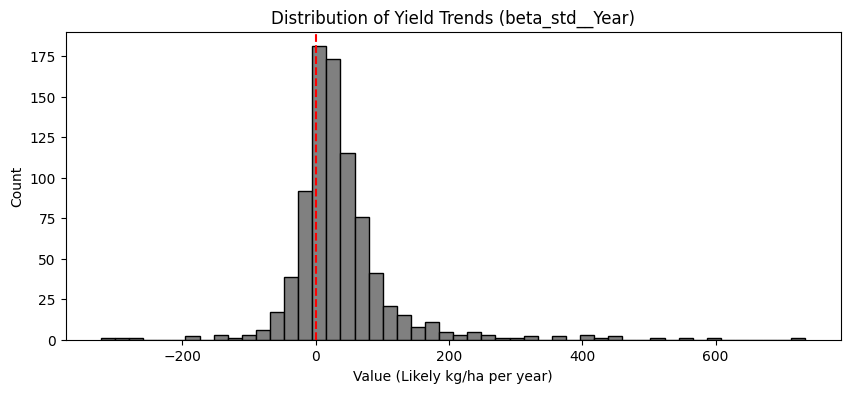


--- Generating Corrected Trend Maps (kg/ha per year) ---


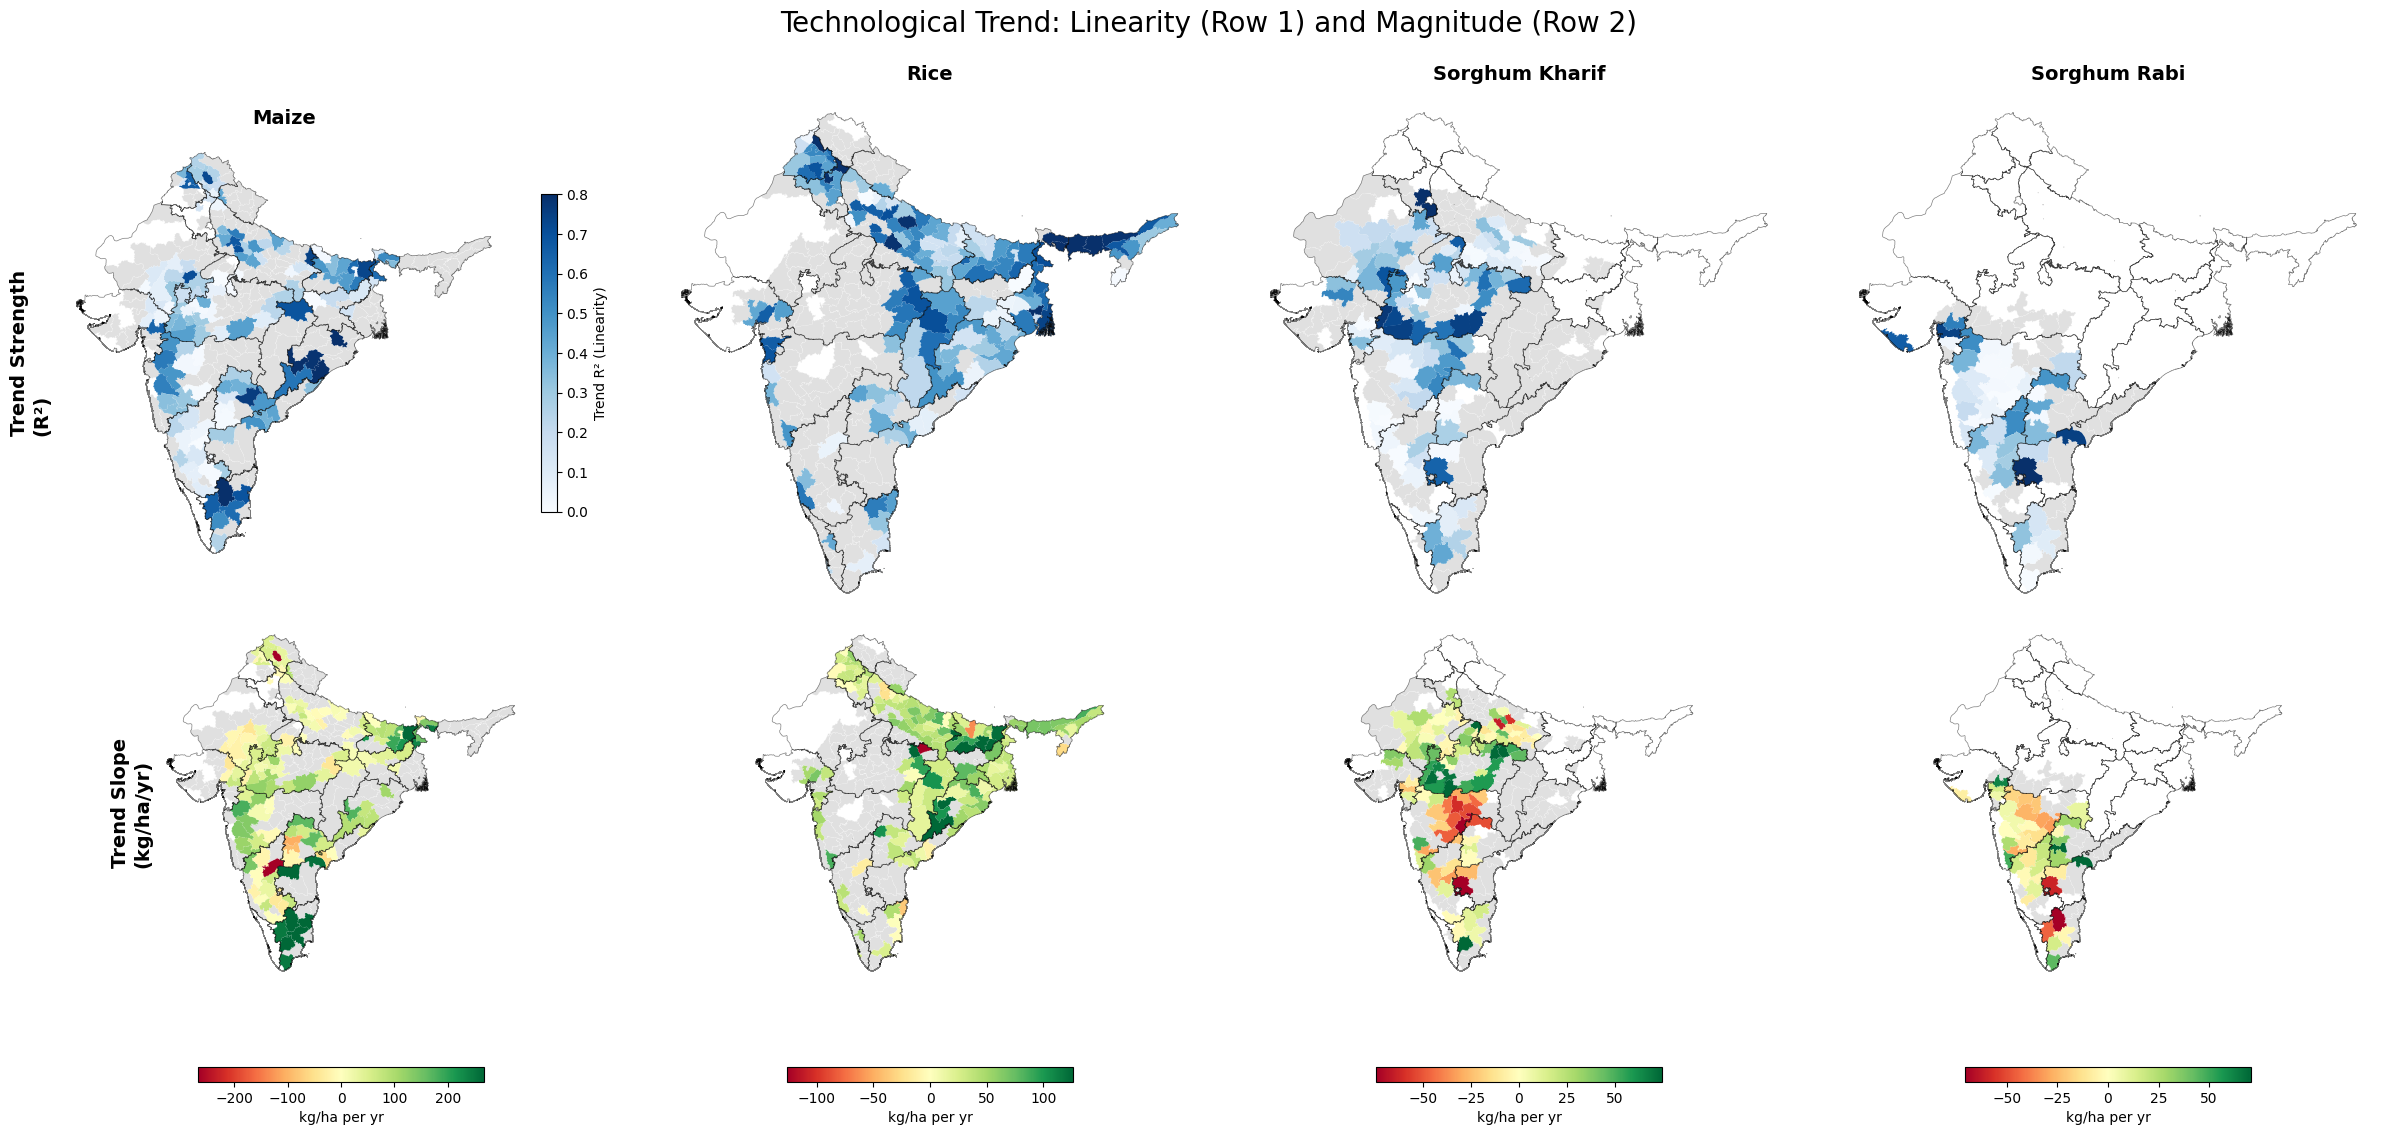

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Corrected Trend Maps (Raw Slope in kg/ha)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

print("--- DIAGNOSIS: Checking Trend Value Ranges ---")

# 1. Check the range of the 'Year' coefficient
# We suspect these are Raw Slopes (kg/ha/yr), not Standardized Betas
trend_vals = results_df[results_df['year_shift'] == 0]['beta_std__Year']
print(trend_vals.describe())

# 2. Histogram to visualize the distribution
plt.figure(figsize=(10, 4))
plt.hist(trend_vals, bins=50, color='gray', edgecolor='black')
plt.title("Distribution of Yield Trends (beta_std__Year)")
plt.xlabel("Value (Likely kg/ha per year)")
plt.ylabel("Count")
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

# ---------------------------------------------------------
# GENERATE CORRECTED MAPS
# ---------------------------------------------------------
print("\n--- Generating Corrected Trend Maps (kg/ha per year) ---")

target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for col_idx, crop in enumerate(crops):

    # Filter Data (Shift 0 + Top 50% Intensity)
    res = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()
    geo_data = districts_gdf.merge(res, on='Dist Code', how='inner')

    cf_df = get_cropping_fraction(crop)
    cutoff = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= cutoff]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < cutoff]

    # --- ROW 1: Trend Strength (R2) ---
    # Unchanged, this was correct
    ax1 = axes[0, col_idx]
    if not bottom_50.empty:
        bottom_50.plot(ax=ax1, color='#e0e0e0', edgecolor='white', linewidth=0.1)
    if not top_50.empty:
        top_50.plot(
            column='R2_1_Trend',
            ax=ax1,
            cmap='Blues',
            vmin=0, vmax=0.8,
            legend=(col_idx==0),
            legend_kwds={'label': 'Trend R² (Linearity)', 'shrink': 0.6}
        )
    state_boundaries_gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax1.set_axis_off()
    ax1.set_title(f"{crop.replace('_', ' ').title()}", fontsize=14, fontweight='bold')

    # --- ROW 2: Trend Direction (Raw Slope) ---
    # FIXED: Adjusted vmin/vmax to typical kg/ha ranges
    ax2 = axes[1, col_idx]
    if not bottom_50.empty:
        bottom_50.plot(ax=ax2, color='#e0e0e0', edgecolor='white', linewidth=0.1)

    if not top_50.empty:
        # Dynamic Range: Set limits based on the specific crop's data
        # Rice yields are huge (need +/- 100), Sorghum is small (need +/- 30)
        vals = top_50['beta_std__Year']
        limit = np.percentile(np.abs(vals), 95) # Robust max to ignore outliers

        # Ensure the limit is at least 10 to avoid tiny ranges
        limit = max(limit, 10)

        div_norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

        top_50.plot(
            column='beta_std__Year',
            ax=ax2,
            cmap='RdYlGn',
            norm=div_norm,
            legend=True, # Show legend for EACH crop now since scales differ
            legend_kwds={'label': 'kg/ha per yr', 'shrink': 0.5, 'location': 'bottom'}
        )

    state_boundaries_gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax2.set_axis_off()

axes[0, 0].text(-0.1, 0.5, "Trend Strength\n(R²)", transform=axes[0, 0].transAxes,
                rotation=90, va='center', fontsize=14, fontweight='bold')
axes[1, 0].text(-0.1, 0.5, "Trend Slope\n(kg/ha/yr)", transform=axes[1, 0].transAxes,
                rotation=90, va='center', fontsize=14, fontweight='bold')

plt.suptitle("Technological Trend: Linearity (Row 1) and Magnitude (Row 2)", fontsize=20, y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Generating 'Nature vs. Infrastructure' Map (Excluding SIF) ---


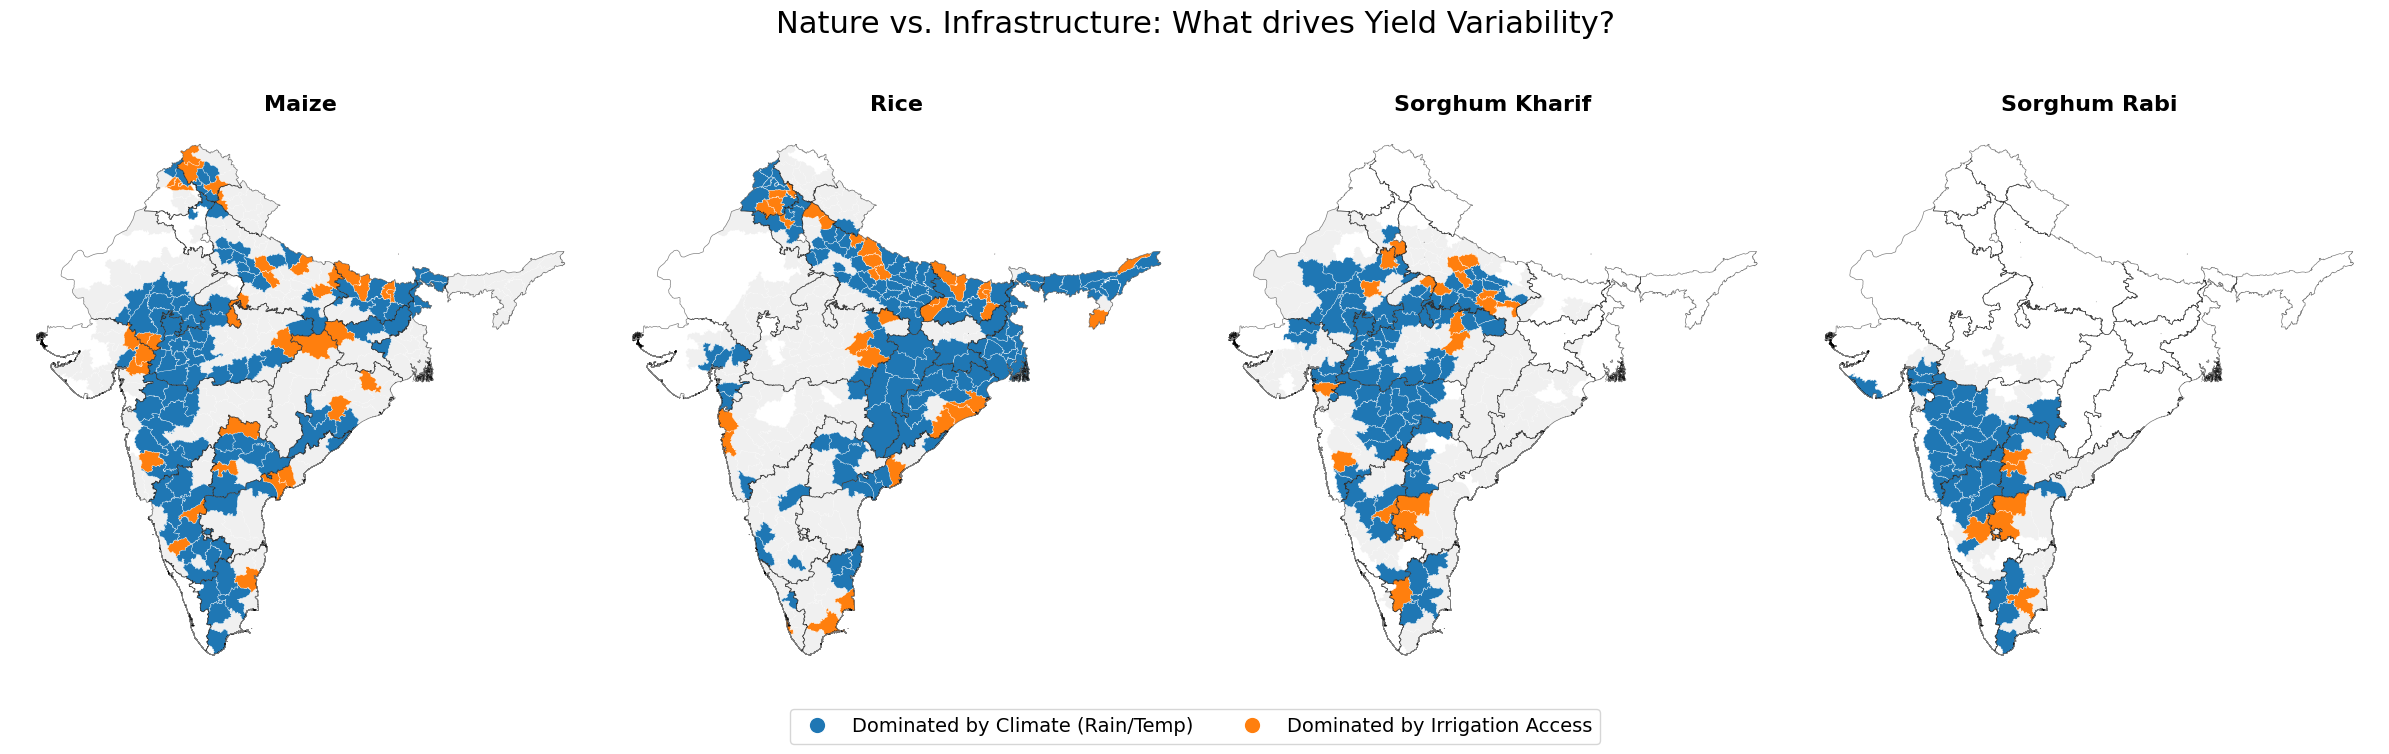


--- Driver Counts (Climate vs. Irrigation) ---


,Climate (%),Irrigation (%)
maize,75.7,24.3
rice,78.9,21.1
sorghum_kharif,80.8,19.2
sorghum_rabi,89.7,10.3


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Nature (Climate) vs. Infrastructure (Irrigation) Map

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("--- Generating 'Nature vs. Infrastructure' Map (Excluding SIF) ---")

# --- Configuration ---
target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# 1. Update Logic: Only compare Climate and Irrigation
def get_abiotic_driver(row):
    # Compare the Marginal Gain of Climate vs. Irrigation
    if row['Mq_Irrig'] > row['Mq_Climate']:
        return 'Irrigation'
    else:
        return 'Climate'

# 2. Simplified Colors
driver_colors = {
    'Climate': '#1f77b4',   # Blue (Water/Weather)
    'Irrigation': '#ff7f0e' # Orange (Infrastructure)
}

# --- Plotting ---
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

for i, crop in enumerate(crops):
    ax = axes[i]

    # A. Get Data
    res = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()
    geo_data = districts_gdf.merge(res, on='Dist Code', how='inner')

    # B. Determine Driver (Excluding SIF)
    geo_data['driver'] = geo_data.apply(get_abiotic_driver, axis=1)
    geo_data['color'] = geo_data['driver'].map(driver_colors)

    # C. Filter Top 50%
    cf_df = get_cropping_fraction(crop)
    cutoff = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= cutoff]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < cutoff]

    # D. Plot Background
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # E. Plot Foreground
    if not top_50.empty:
        top_50.plot(
            color=top_50['color'],
            ax=ax,
            edgecolor='white',
            linewidth=0.2
        )

    # F. Boundaries
    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)

    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

# --- Legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=driver_colors['Climate'], label='Dominated by Climate (Rain/Temp)', markersize=12),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=driver_colors['Irrigation'], label='Dominated by Irrigation Access', markersize=12)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 0.05))

plt.suptitle("Nature vs. Infrastructure: What drives Yield Variability?", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

# --- Summary Table ---
print("\n--- Driver Counts (Climate vs. Irrigation) ---")
summary_stats = []
for crop in crops:
    cf_df = get_cropping_fraction(crop)
    threshold = cf_df['cropping_fraction'].quantile(0.5)
    res = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].merge(cf_df, on='Dist Code')
    top_50 = res[res['cropping_fraction'] >= threshold].copy()

    top_50['driver'] = top_50.apply(get_abiotic_driver, axis=1)
    counts = top_50['driver'].value_counts(normalize=True) * 100 # Percentage
    counts.name = crop
    summary_stats.append(counts)

summary_df = pd.DataFrame(summary_stats).fillna(0).round(1)
summary_df.columns = [f"{c} (%)" for c in summary_df.columns]
display(summary_df)

--- Generating Strict Dominance Map (Improved Palette) ---


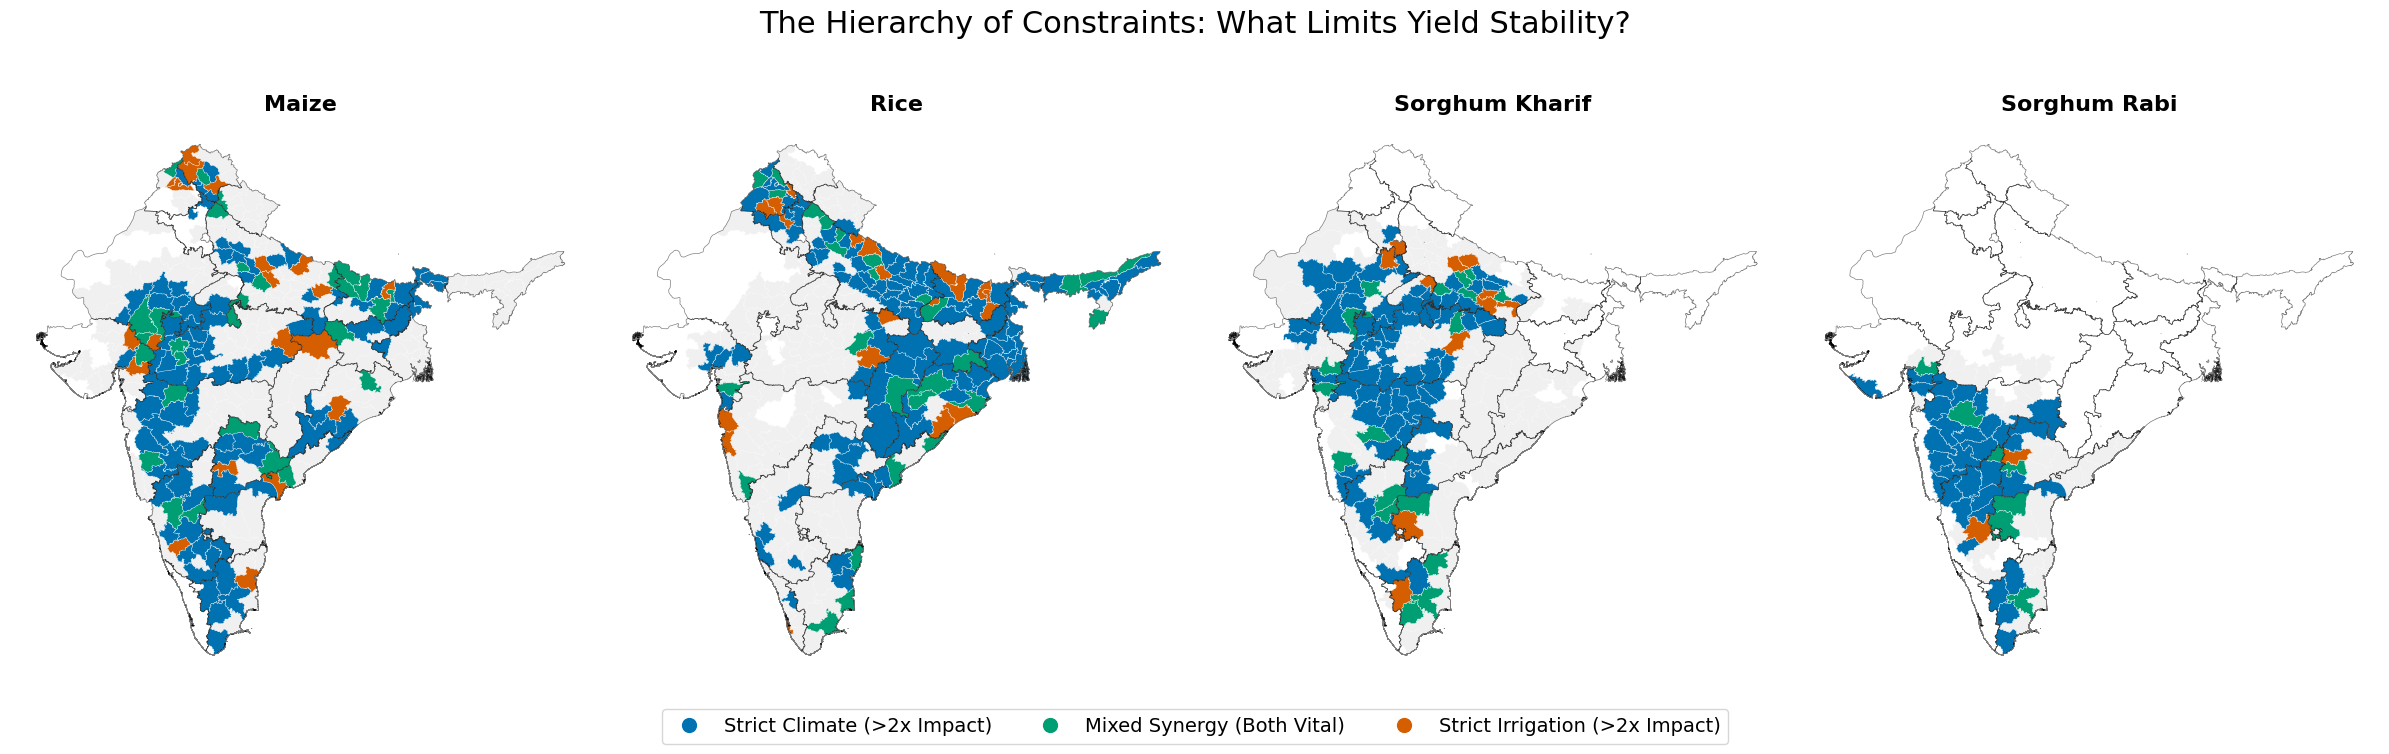


--- Strict Driver Counts (Top 50% Districts) ---


,Climate (%),Mixed (%),Irrigation (%)
maize,65.7,19.3,15.0
rice,68.3,19.0,12.7
sorghum_kharif,71.2,18.3,10.6
sorghum_rabi,82.1,12.8,5.1


In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# RE-RUN CELL: Strict Drivers with Improved Color Palette

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("--- Generating Strict Dominance Map (Improved Palette) ---")

# --- Configuration ---
target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# 1. Logic (Same as before: >2x threshold)
def get_strict_abiotic_driver(row):
    c = max(0, row['Mq_Climate'])
    i = max(0, row['Mq_Irrig'])

    if c > (2 * i):
        return 'Climate'
    elif i > (2 * c):
        return 'Irrigation'
    else:
        return 'Mixed'

# 2. NEW Color Palette (Colorblind Friendly & Intuitive)
# Blue = Water/Nature
# Red/Orange = Infrastructure/Built
# Green = Synergy
driver_colors = {
    'Climate': '#0072B2',    # Strong Blue
    'Irrigation': '#D55E00',  # Vermillion (Red-Orange)
    'Mixed': '#009E73'        # Bluish Green (Teal)
}

# --- Plotting ---
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

for i, crop in enumerate(crops):
    ax = axes[i]

    # A. Get Data
    res = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()
    geo_data = districts_gdf.merge(res, on='Dist Code', how='inner')

    # B. Determine Driver
    geo_data['driver'] = geo_data.apply(get_strict_abiotic_driver, axis=1)
    geo_data['color'] = geo_data['driver'].map(driver_colors)

    # C. Filter Top 50%
    cf_df = get_cropping_fraction(crop)
    cutoff = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= cutoff]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < cutoff]

    # D. Plot Background
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # E. Plot Foreground
    if not top_50.empty:
        top_50.plot(
            color=top_50['color'],
            ax=ax,
            edgecolor='white',
            linewidth=0.2
        )

    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

# --- Legend ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=driver_colors['Climate'], label='Strict Climate (>2x Impact)', markersize=12),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=driver_colors['Mixed'], label='Mixed Synergy (Both Vital)', markersize=12),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=driver_colors['Irrigation'], label='Strict Irrigation (>2x Impact)', markersize=12)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 0.05))

plt.suptitle("The Hierarchy of Constraints: What Limits Yield Stability?", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

# --- Summary Table ---
print("\n--- Strict Driver Counts (Top 50% Districts) ---")
summary_stats = []
for crop in crops:
    cf_df = get_cropping_fraction(crop)
    threshold = cf_df['cropping_fraction'].quantile(0.5)
    res = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].merge(cf_df, on='Dist Code')
    top_50 = res[res['cropping_fraction'] >= threshold].copy()

    top_50['driver'] = top_50.apply(get_strict_abiotic_driver, axis=1)
    counts = top_50['driver'].value_counts(normalize=True) * 100
    counts.name = crop
    summary_stats.append(counts)

summary_df = pd.DataFrame(summary_stats).fillna(0).round(1)
cols = ['Climate', 'Mixed', 'Irrigation']
summary_df = summary_df[[c for c in cols if c in summary_df.columns]]
summary_df.columns = [f"{c} (%)" for c in summary_df.columns]
display(summary_df)

--- Generating Winning Shift Maps (Climate Signal Only) ---
    Metric: Max(R2_Climate - R2_Trend)


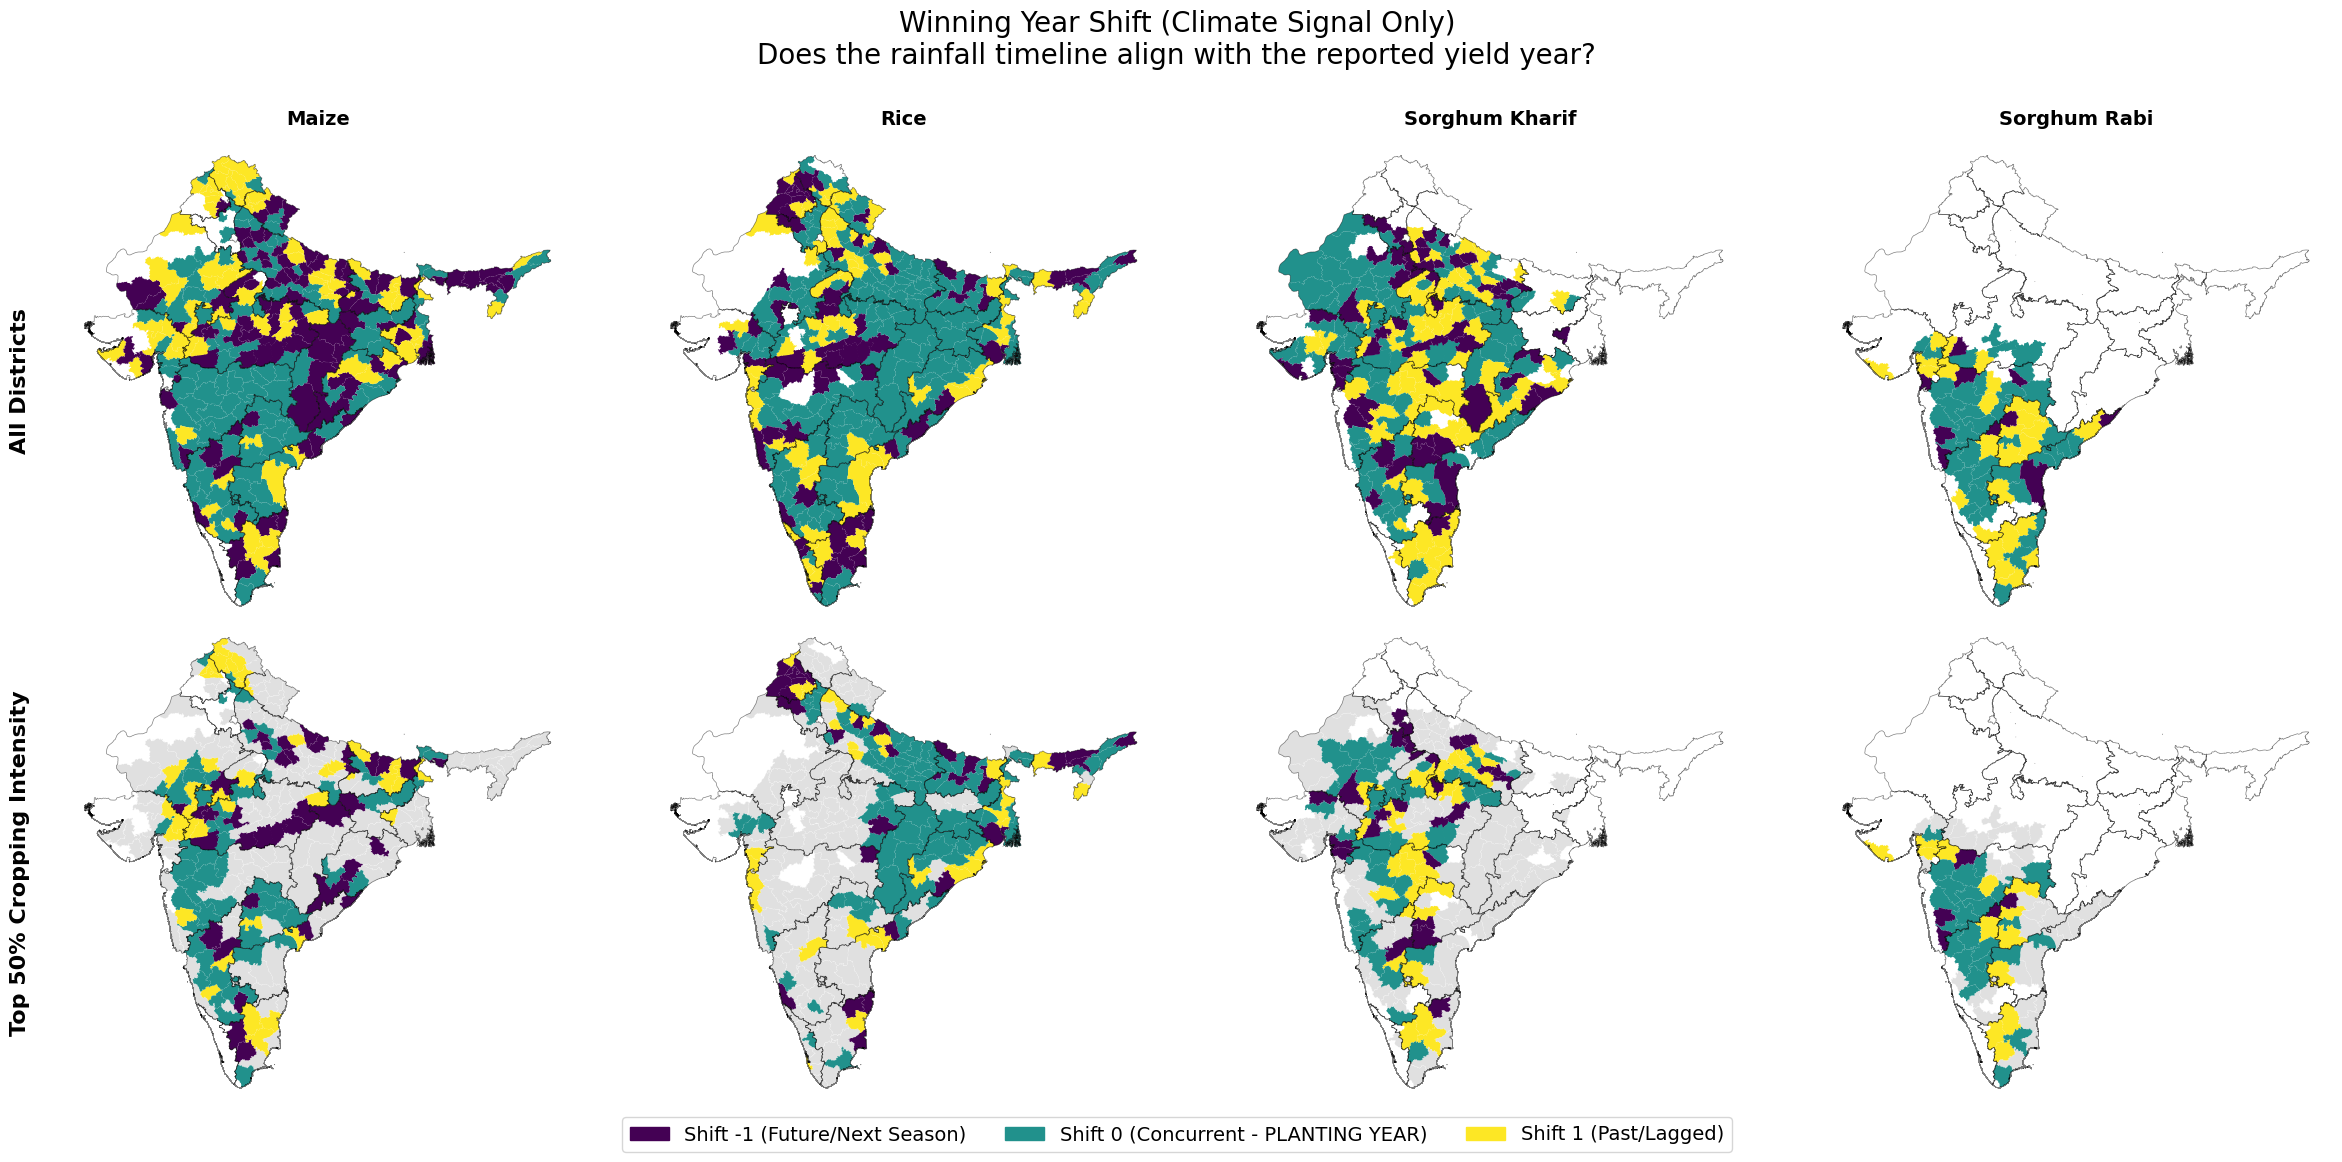

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Winning Shift Map (Climate Signal Only)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("--- Generating Winning Shift Maps (Climate Signal Only) ---")
print("    Metric: Max(R2_Climate - R2_Trend)")

# 1. Define Winner Logic based on CLIMATE ONLY
# We look at which shift maximizes the marginal gain of adding Climate
results_df['Climate_Gain'] = results_df['R2_2_Climate'] - results_df['R2_1_Trend']
idx = results_df.groupby(['Dist Code', 'crop'])['Climate_Gain'].idxmax()
best_shift_climate_df = results_df.loc[idx].copy()

# 2. Setup Coloring & Layout
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
titles = ["Maize", "Rice", "Sorghum Kharif", "Sorghum Rabi"]

# Explicit Color Mapping
color_map = {
    -1: '#440154', # Purple (Future/Next Season)
     0: '#21918c', # Teal   (Concurrent/Standard)
     1: '#fde725'  # Yellow (Past/Lagged)
}

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

# Create Figure
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
rows = ["All Districts", "Top 50% Cropping Intensity"]

for col_idx, crop in enumerate(crops):
    # A. Prepare Data
    crop_results = best_shift_climate_df[best_shift_climate_df['crop'] == crop]
    geo_data = districts_gdf.merge(crop_results, on='Dist Code', how='inner')

    # B. Calculate Intensity
    cf_df = get_cropping_fraction(crop)
    threshold = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')

    # --- ROW 1: All Districts ---
    ax1 = axes[0, col_idx]
    geo_data.plot(
        color=geo_data['year_shift'].map(color_map),
        ax=ax1
    )
    state_boundaries_gdf.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax1.set_axis_off()
    ax1.set_title(f"{titles[col_idx]}", fontsize=14, fontweight='bold')

    # --- ROW 2: Top 50% Intensity ---
    ax2 = axes[1, col_idx]

    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    # Background
    if not bottom_50.empty:
        bottom_50.plot(ax=ax2, color='#e0e0e0', edgecolor='white', linewidth=0.1)

    # Foreground
    if not top_50.empty:
        top_50.plot(
            color=top_50['year_shift'].map(color_map),
            ax=ax2
        )

    state_boundaries_gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax2.set_axis_off()

# --- Decoration ---
for r, label in enumerate(rows):
    axes[r, 0].text(-0.1, 0.5, label, transform=axes[r, 0].transAxes,
                    rotation=90, va='center', fontsize=16, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=color_map[-1], label='Shift -1 (Future/Next Season)'),
    mpatches.Patch(color=color_map[0],  label='Shift 0 (Concurrent - PLANTING YEAR)'),
    mpatches.Patch(color=color_map[1],  label='Shift 1 (Past/Lagged)')
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 0.02))

plt.suptitle("Winning Year Shift (Climate Signal Only)\nDoes the rainfall timeline align with the reported yield year?", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

--- Generating Cumulative Partial R² Visualization (Shared Scale) ---
    Row 1: Climate Only (vs Trend)
    Row 2: Climate + Irrigation (vs Trend)
    Row 3: Full Model (Climate + Irrig + SIF vs Trend)


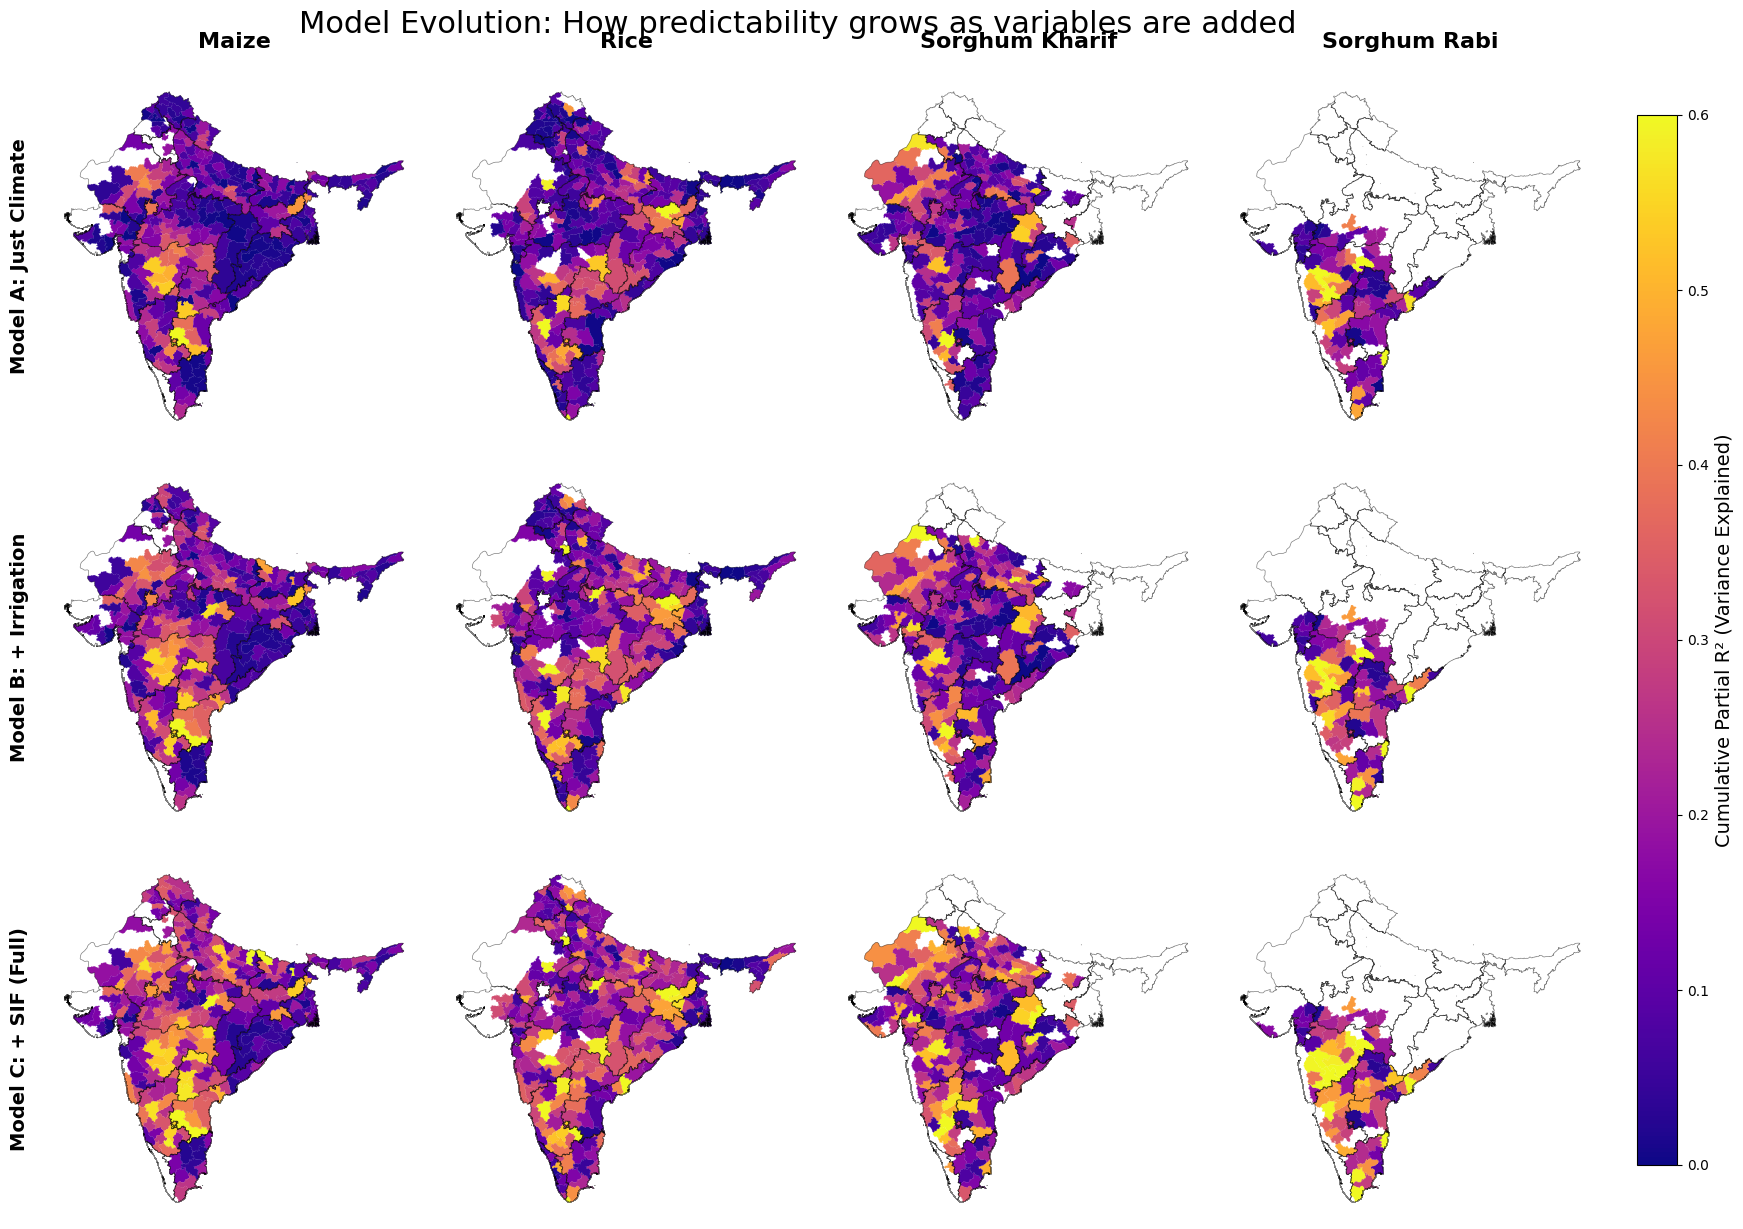

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: 3-Row Cumulative Partial R2 (The "Growth" of the Model)

import matplotlib.pyplot as plt

print("--- Generating Cumulative Partial R² Visualization (Shared Scale) ---")
print("    Row 1: Climate Only (vs Trend)")
print("    Row 2: Climate + Irrigation (vs Trend)")
print("    Row 3: Full Model (Climate + Irrig + SIF vs Trend)")

# --- Configuration ---
target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# We define the columns to SUBTRACT Trend from
metric_cols = ['R2_2_Climate', 'R2_3_Irrig', 'R2_4_Full']
row_labels = ['Model A: Just Climate', 'Model B: + Irrigation', 'Model C: + SIF (Full)']

# SCALE: 0.0 to 0.6 (To match the overall predictability map)
V_MIN = 0.0
V_MAX = 0.6

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

# Setup Figure
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for col_idx, crop in enumerate(crops):

    # 1. Prepare Data (Shift 0)
    res = results_df[(results_df['crop'] == crop) & (results_df['year_shift'] == target_shift)].copy()

    # 2. Calculate Cumulative Partials
    # (Total Variance Explained by that stage - Variance Explained by Trend)
    res['Partial_Step1'] = res['R2_2_Climate'] - res['R2_1_Trend']
    res['Partial_Step2'] = res['R2_3_Irrig']   - res['R2_1_Trend']
    res['Partial_Step3'] = res['R2_4_Full']    - res['R2_1_Trend']

    plot_cols = ['Partial_Step1', 'Partial_Step2', 'Partial_Step3']

    geo_data = districts_gdf.merge(res, on='Dist Code', how='inner')

    # Loop through Rows (Cumulative Steps)
    for row_idx, p_col in enumerate(plot_cols):
        ax = axes[row_idx, col_idx]

        # Plot (All Districts - No Filtering)
        geo_data.plot(
            column=p_col,
            ax=ax,
            cmap='plasma', # Blue (Low) -> Red -> Yellow (High)
            vmin=V_MIN, vmax=V_MAX,
            edgecolor='face',
            linewidth=0.1
        )

        # Boundaries
        state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
        ax.set_axis_off()

        # Titles
        if row_idx == 0:
            ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=16, fontweight='bold', pad=20)

        if col_idx == 0:
            ax.text(-0.1, 0.5, row_labels[row_idx], transform=ax.transAxes,
                    rotation=90, va='center', fontsize=14, fontweight='bold')

# --- Shared Colorbar ---
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=V_MIN, vmax=V_MAX))
sm._A = []
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Cumulative Partial R² (Variance Explained)', fontsize=14)

plt.suptitle("Model Evolution: How predictability grows as variables are added", fontsize=22, y=0.92)
plt.subplots_adjust(wspace=0.05, hspace=0.05, right=0.9)
plt.show()

--- Generating Shift Comparison Scatter Plots (District Level) ---
    X-Axis: Shift 0 (Planting Year)
    Y-Axis: Shift -1 (Harvest/Next Year)
    Metric: Total Partial R² (Full Model - Trend)


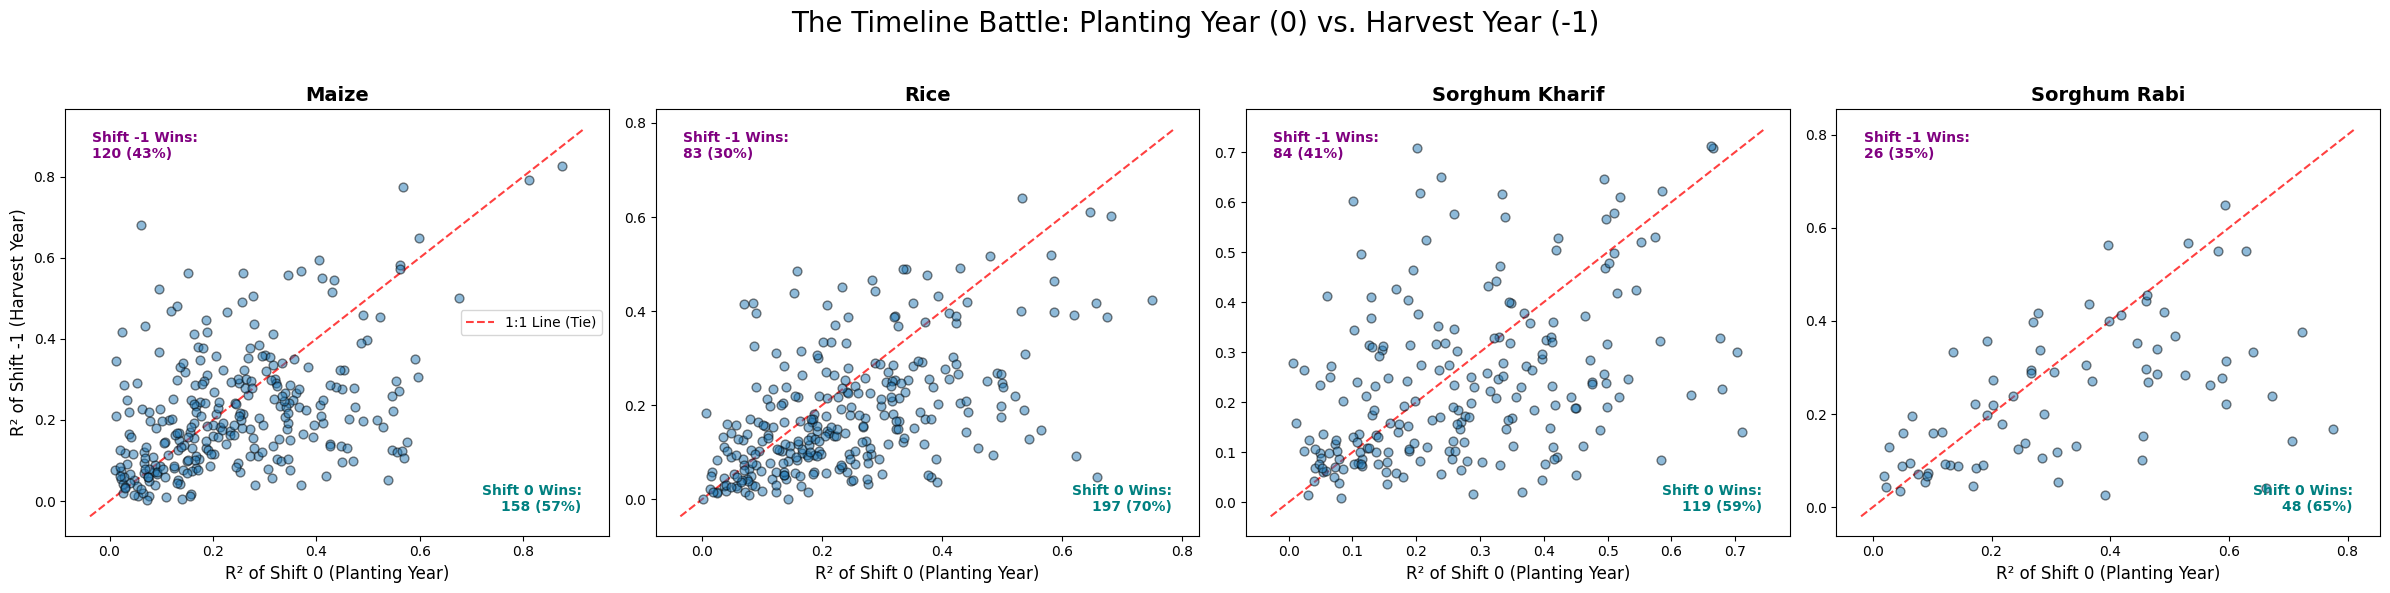

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Shift Comparison Scatter Plot (1:1 Analysis)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Generating Shift Comparison Scatter Plots (District Level) ---")
print("    X-Axis: Shift 0 (Planting Year)")
print("    Y-Axis: Shift -1 (Harvest/Next Year)")
print("    Metric: Total Partial R² (Full Model - Trend)")

# --- Configuration ---
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Setup Figure
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Pivot the Data
    # We filter for the specific crop
    df_crop = results_df[results_df['crop'] == crop].copy()

    # Calculate Metric: Partial R2 (Variance explained by Climate+Irrig+SIF)
    df_crop['Partial_R2'] = df_crop['R2_4_Full'] - df_crop['R2_1_Trend']

    # Pivot so we have columns for Shift 0 and Shift -1 side-by-side
    pivot = df_crop.pivot(index='Dist Code', columns='year_shift', values='Partial_R2')

    # Drop rows that don't have both shifts (just in case)
    pivot = pivot.dropna(subset=[0, -1])

    # 2. Scatter Plot
    # X = Shift 0, Y = Shift -1
    ax.scatter(pivot[0], pivot[-1], alpha=0.5, c='#1f77b4', edgecolor='k', s=40)

    # 3. Add 1:1 Line (The "Tie" Line)
    # Get plot limits to draw the line across the whole box
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='1:1 Line (Tie)')

    # 4. Styling & Labels
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("R² of Shift 0 (Planting Year)", fontsize=12)

    if i == 0:
        ax.set_ylabel("R² of Shift -1 (Harvest Year)", fontsize=12)
        ax.legend()

    # 5. Annotation (Winner Counts)
    # Count how many dots are below the line (Shift 0 wins) vs above (Shift -1 wins)
    shift0_wins = (pivot[0] > pivot[-1]).sum()
    shiftneg1_wins = (pivot[-1] > pivot[0]).sum()
    total = len(pivot)

    # Text in bottom-right (Shift 0 region)
    ax.text(0.95, 0.05, f"Shift 0 Wins:\n{shift0_wins} ({shift0_wins/total:.0%})",
            transform=ax.transAxes, ha='right', va='bottom', color='teal', fontweight='bold')

    # Text in top-left (Shift -1 region)
    ax.text(0.05, 0.95, f"Shift -1 Wins:\n{shiftneg1_wins} ({shiftneg1_wins/total:.0%})",
            transform=ax.transAxes, ha='left', va='top', color='purple', fontweight='bold')

plt.suptitle("The Timeline Battle: Planting Year (0) vs. Harvest Year (-1)", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Generating Shift Comparison Scatter Plots (Lagged Analysis) ---
    X-Axis: Shift 0 (Current/Planting Year)
    Y-Axis: Shift +1 (Past/Lagged Year)
    Hypothesis: If Y > X, the crop relies on stored water (Groundwater/Reservoirs).


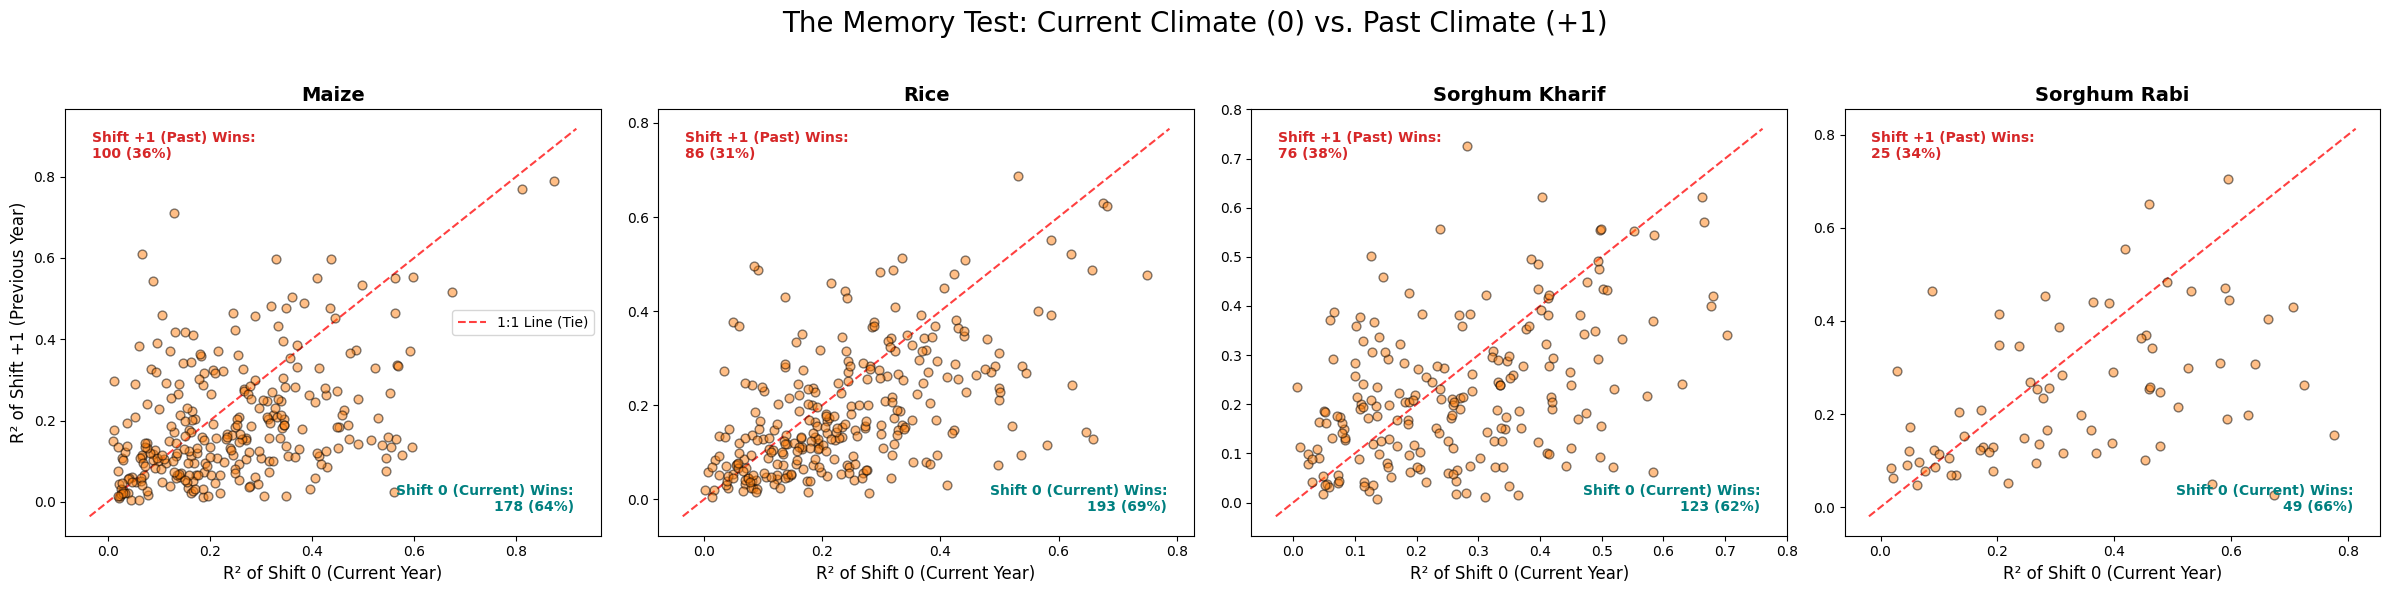

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Shift Comparison Scatter Plot (0 vs +1)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Generating Shift Comparison Scatter Plots (Lagged Analysis) ---")
print("    X-Axis: Shift 0 (Current/Planting Year)")
print("    Y-Axis: Shift +1 (Past/Lagged Year)")
print("    Hypothesis: If Y > X, the crop relies on stored water (Groundwater/Reservoirs).")

# --- Configuration ---
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Setup Figure
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Pivot the Data
    df_crop = results_df[results_df['crop'] == crop].copy()

    # Calculate Metric: Partial R2
    df_crop['Partial_R2'] = df_crop['R2_4_Full'] - df_crop['R2_1_Trend']

    # Pivot (We need columns 0 and 1)
    pivot = df_crop.pivot(index='Dist Code', columns='year_shift', values='Partial_R2')

    # Drop rows that don't have both
    pivot = pivot.dropna(subset=[0, 1])

    # 2. Scatter Plot
    # X = Shift 0, Y = Shift 1
    # We use Orange for the dots to distinguish from the previous plot
    ax.scatter(pivot[0], pivot[1], alpha=0.5, c='#ff7f0e', edgecolor='k', s=40)

    # 3. Add 1:1 Line
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='1:1 Line (Tie)')

    # 4. Styling
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("R² of Shift 0 (Current Year)", fontsize=12)

    if i == 0:
        ax.set_ylabel("R² of Shift +1 (Previous Year)", fontsize=12)
        ax.legend()

    # 5. Annotation
    shift0_wins = (pivot[0] > pivot[1]).sum()
    shift1_wins = (pivot[1] > pivot[0]).sum()
    total = len(pivot)

    # Text
    ax.text(0.95, 0.05, f"Shift 0 (Current) Wins:\n{shift0_wins} ({shift0_wins/total:.0%})",
            transform=ax.transAxes, ha='right', va='bottom', color='teal', fontweight='bold')

    ax.text(0.05, 0.95, f"Shift +1 (Past) Wins:\n{shift1_wins} ({shift1_wins/total:.0%})",
            transform=ax.transAxes, ha='left', va='top', color='#d62728', fontweight='bold')

plt.suptitle("The Memory Test: Current Climate (0) vs. Past Climate (+1)", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Generating Shift Comparison: Past (+1) vs. Future (-1) ---
    X-Axis: Shift +1 (Past Year / Lagged)
    Y-Axis: Shift -1 (Future Year / Next Season)
    Gap: 2 Years separation.


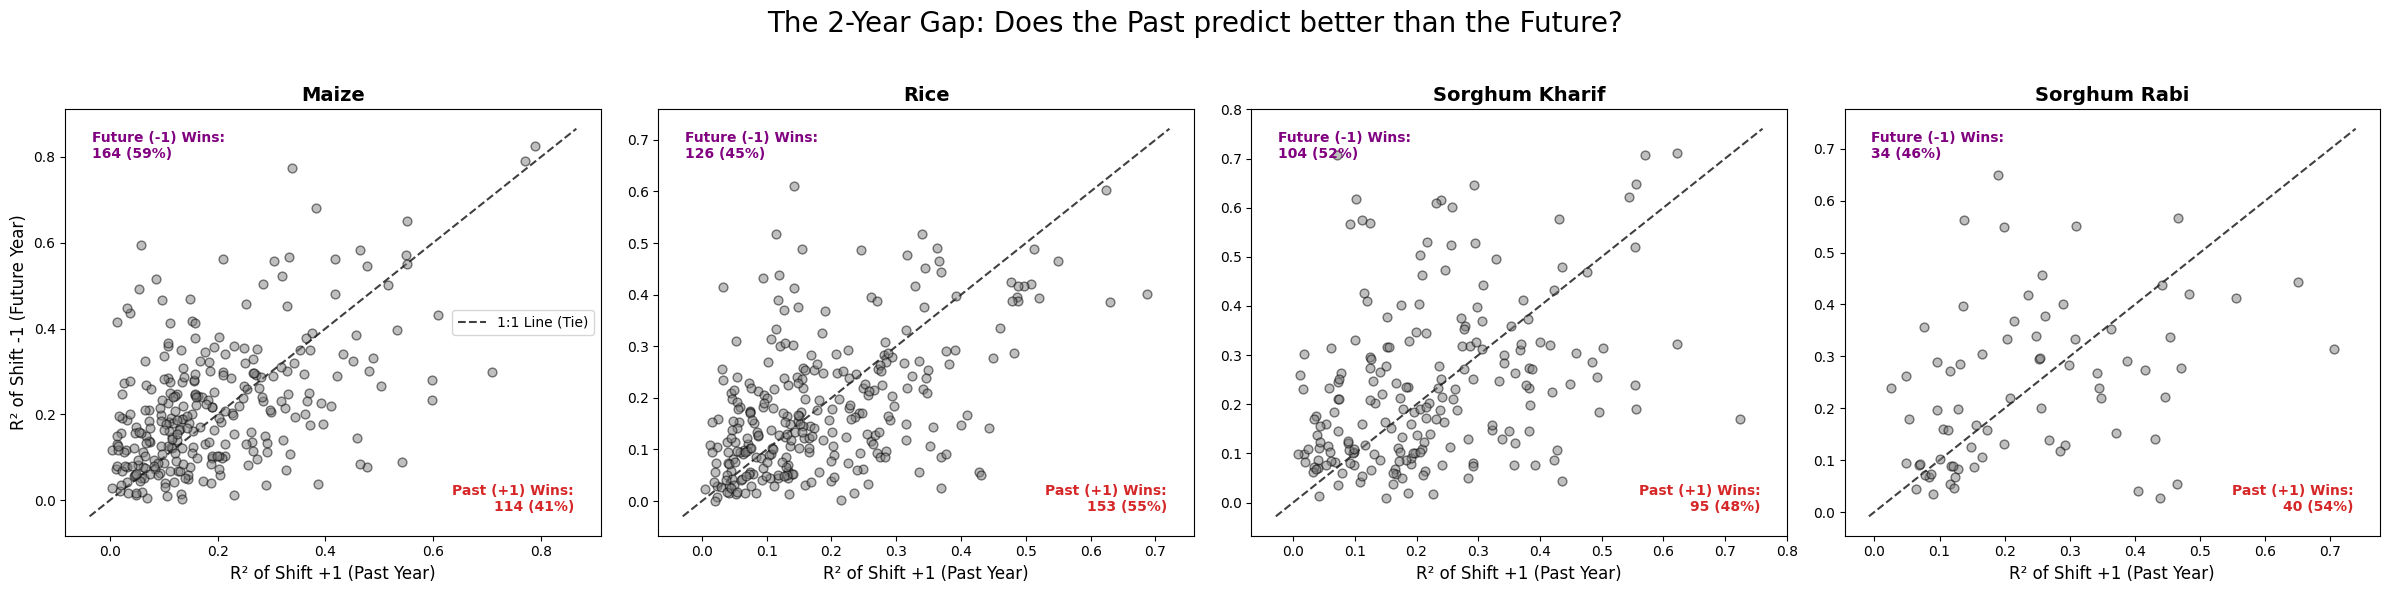

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Shift Comparison (Past vs. Future)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Generating Shift Comparison: Past (+1) vs. Future (-1) ---")
print("    X-Axis: Shift +1 (Past Year / Lagged)")
print("    Y-Axis: Shift -1 (Future Year / Next Season)")
print("    Gap: 2 Years separation.")

# --- Configuration ---
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Setup Figure
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Pivot the Data
    df_crop = results_df[results_df['crop'] == crop].copy()

    # Metric: Partial R2
    df_crop['Partial_R2'] = df_crop['R2_4_Full'] - df_crop['R2_1_Trend']

    # Pivot (We need columns 1 and -1)
    pivot = df_crop.pivot(index='Dist Code', columns='year_shift', values='Partial_R2')

    # Drop rows that don't have both
    pivot = pivot.dropna(subset=[1, -1])

    # 2. Scatter Plot
    # X = Shift +1 (Past), Y = Shift -1 (Future)
    # Using Red (Past) vs Purple (Future) coloring logic
    ax.scatter(pivot[1], pivot[-1], alpha=0.5, c='gray', edgecolor='k', s=40)

    # 3. Add 1:1 Line
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='1:1 Line (Tie)')

    # 4. Styling
    ax.set_title(f"{crop.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("R² of Shift +1 (Past Year)", fontsize=12)

    if i == 0:
        ax.set_ylabel("R² of Shift -1 (Future Year)", fontsize=12)
        ax.legend()

    # 5. Annotation
    past_wins = (pivot[1] > pivot[-1]).sum()
    future_wins = (pivot[-1] > pivot[1]).sum()
    total = len(pivot)

    # Text
    ax.text(0.95, 0.05, f"Past (+1) Wins:\n{past_wins} ({past_wins/total:.0%})",
            transform=ax.transAxes, ha='right', va='bottom', color='#d62728', fontweight='bold')

    ax.text(0.05, 0.95, f"Future (-1) Wins:\n{future_wins} ({future_wins/total:.0%})",
            transform=ax.transAxes, ha='left', va='top', color='purple', fontweight='bold')

plt.suptitle("The 2-Year Gap: Does the Past predict better than the Future?", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL (Place at end): Load Quadratic vs Linear Data for Comparison

print("--- Preparing Data for Quadratic Impact Analysis ---")

# 1. Define Paths
LINEAR_FILE = "results/FINAL_HIERARCHICAL_metrics.parquet"
QUAD_FILE   = "results/FINAL_HIERARCHICAL_QUADRATIC_metrics.parquet"

# 2. Load
try:
    df_lin = pd.read_parquet(LINEAR_FILE)
    df_quad = pd.read_parquet(QUAD_FILE)
    print(f"Loaded Linear: {len(df_lin)} | Loaded Quad: {len(df_quad)}")
except FileNotFoundError as e:
    print(f"ERROR: Missing files. Ensure you ran Notebook 02 for both models. {e}")

# 3. Filter for Shift 0 (Planting Year) ONLY
# We strictly compare the "Best" linear vs "Best" quadratic
df_lin = df_lin[df_lin['year_shift'] == 0].copy()
df_quad = df_quad[df_quad['year_shift'] == 0].copy()

# 4. Merge
# Inner join to ensure we only look at districts that survived the stricter
# 15-year threshold of the quadratic model.
comp_df = pd.merge(
    df_lin,
    df_quad,
    on=['Dist Code', 'crop'],
    suffixes=('_lin', '_quad'),
    how='inner'
)

# 5. Calculate the Metric: "Quadratic Boost"
# How much MORE variance does Climate explain when we add squares?
comp_df['Quadratic_Boost'] = comp_df['Mq_Climate_quad'] - comp_df['Mq_Climate_lin']

print(f"Comparison Data Ready: {len(comp_df)} district-crop pairs.")
print("Metric 'Quadratic_Boost' calculated.")

--- Preparing Data for Quadratic Impact Analysis ---
Loaded Linear: 2504 | Loaded Quad: 2324
Comparison Data Ready: 788 district-crop pairs.
Metric 'Quadratic_Boost' calculated.


--- Mapping Non-Linearity (Top 50% Cropping Intensity) ---
    Visualizing: Where does Heat/Water Stress (Quadratic) explain more yield variance?


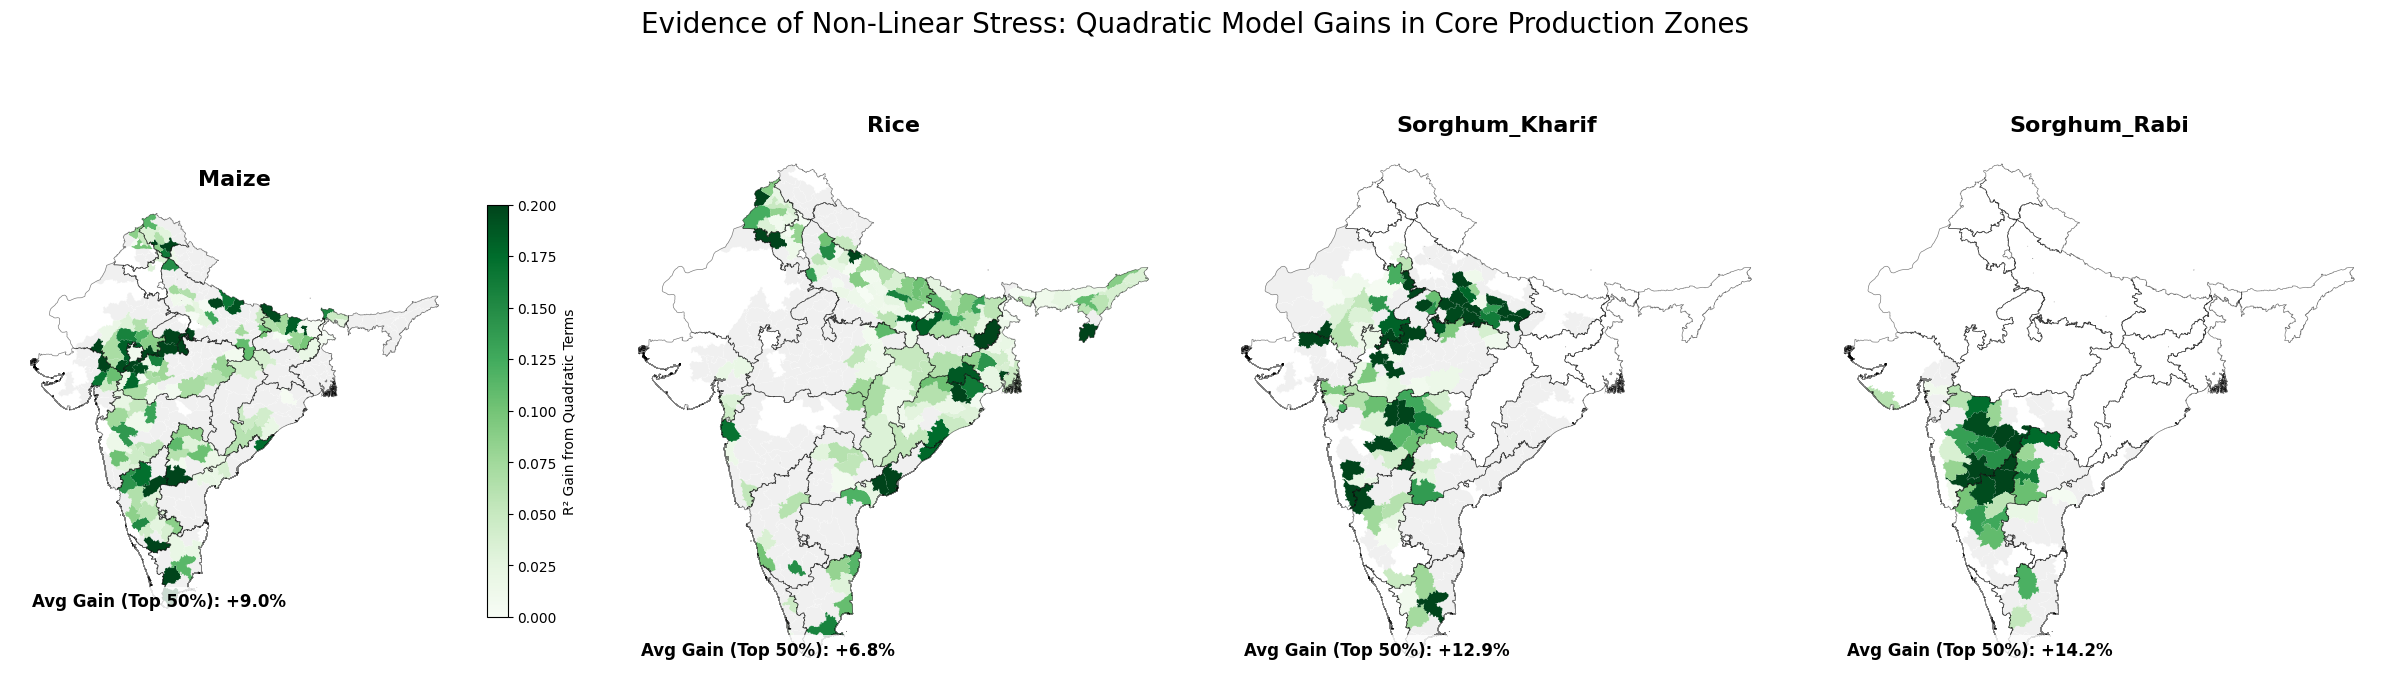

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Plotting Quadratic Boost (Top 50% Intensity)

import matplotlib.pyplot as plt

print("--- Mapping Non-Linearity (Top 50% Cropping Intensity) ---")
print("    Visualizing: Where does Heat/Water Stress (Quadratic) explain more yield variance?")

# --- Configuration ---
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

# Setup Figure
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Get Comparison Data for this crop
    data = comp_df[comp_df['crop'] == crop].copy()

    # 2. Merge with Geometry
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # 3. Get Cropping Intensity & Filter
    cf_df = get_cropping_fraction(crop)
    threshold = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')

    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    # 4. Plot Background (Excluded)
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # 5. Plot Foreground (The Boost)
    if not top_50.empty:
        top_50.plot(
            column='Quadratic_Boost',
            ax=ax,
            cmap='Greens',
            vmin=0, vmax=0.20, # Scale: 0% to 20% gain
            legend=(i==0),
            legend_kwds={'label': 'R² Gain from Quadratic Terms', 'shrink': 0.6}
        )

    # 6. Styling
    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

    # 7. Stats (Only for Top 50%)
    avg_boost = top_50['Quadratic_Boost'].mean()
    ax.text(0.05, 0.05, f"Avg Gain (Top 50%): +{avg_boost*100:.1f}%",
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle("Evidence of Non-Linear Stress: Quadratic Model Gains in Core Production Zones", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Comparing: Quadratic Model vs. Interaction Model ---
    Did adding (Temp * SoilMoisture) improve the signal?


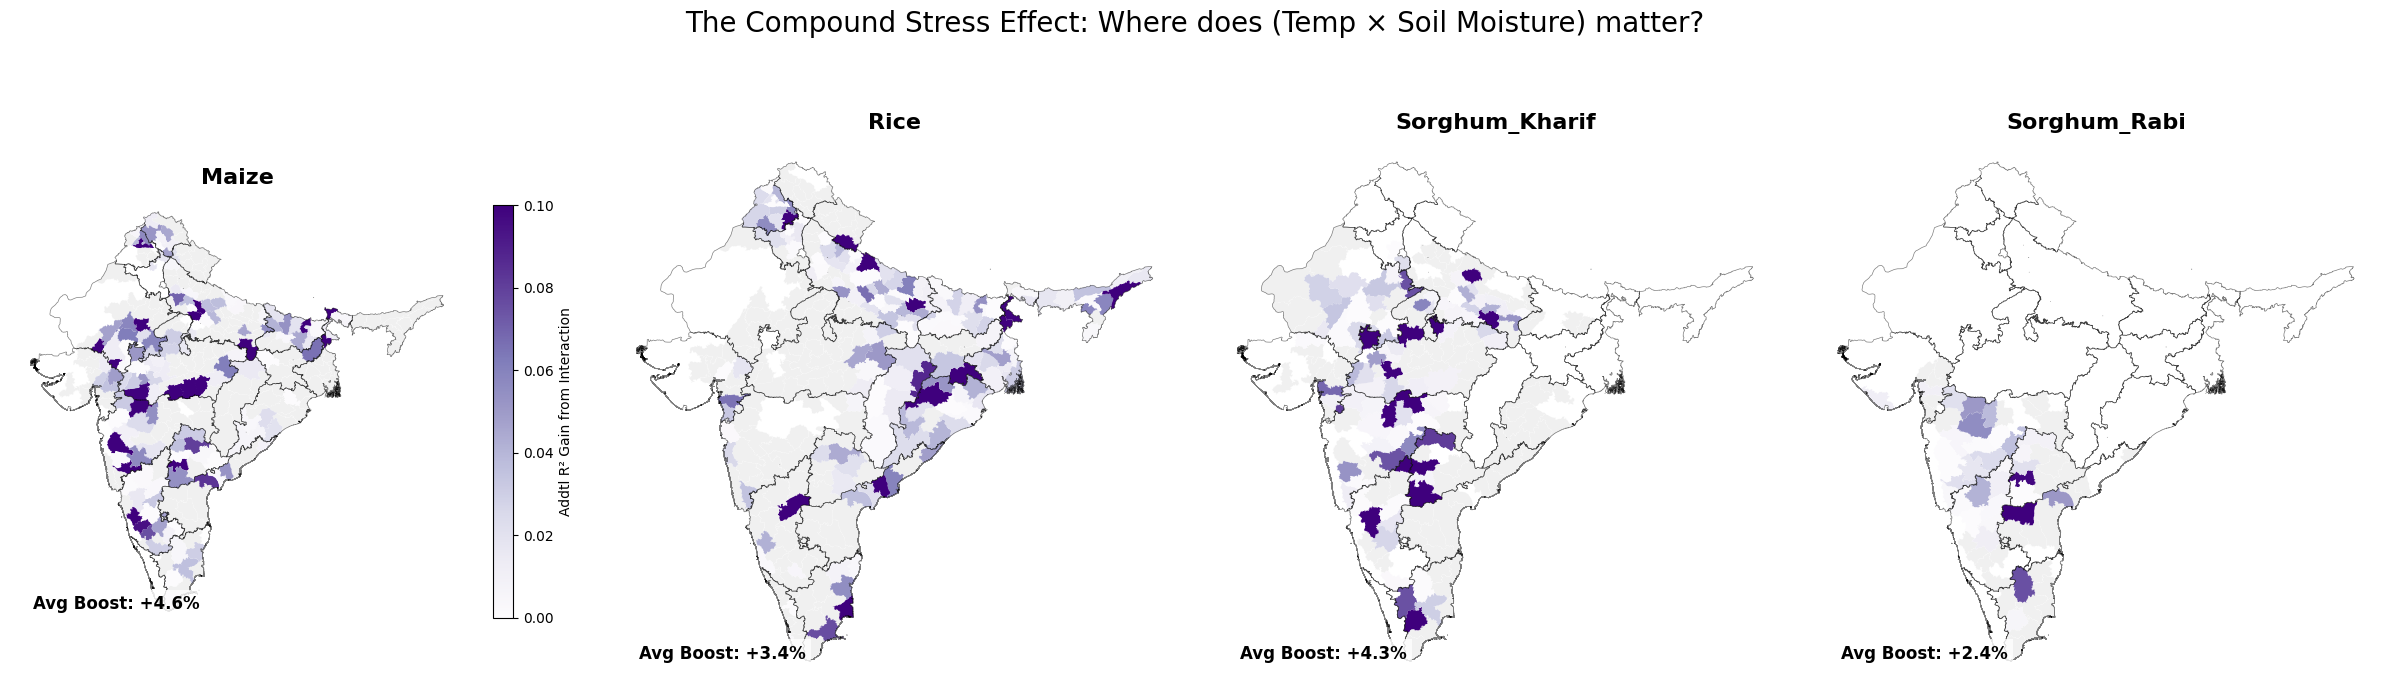

In [ ]:
# FILE: 04_Diagnostic_Plots.ipynb
# NEW CELL: Compare Quadratic vs. Interaction Models

import matplotlib.pyplot as plt
import pandas as pd

print("--- Comparing: Quadratic Model vs. Interaction Model ---")
print("    Did adding (Temp * SoilMoisture) improve the signal?")

# 1. Define Paths
QUAD_FILE = "results/FINAL_HIERARCHICAL_QUADRATIC_metrics.parquet"
INTER_FILE = "results/FINAL_HIERARCHICAL_INTERACTION_metrics.parquet"

# 2. Load
try:
    df_quad = pd.read_parquet(QUAD_FILE)
    df_inter = pd.read_parquet(INTER_FILE)
except FileNotFoundError as e:
    print(f"Wait! You need to run Notebook 02 first. {e}")

# 3. Filter for Shift 0
df_quad = df_quad[df_quad['year_shift'] == 0].copy()
df_inter = df_inter[df_inter['year_shift'] == 0].copy()

# 4. Merge
comp_df = pd.merge(
    df_quad,
    df_inter,
    on=['Dist Code', 'crop'],
    suffixes=('_quad', '_inter'),
    how='inner'
)

# 5. Calculate "Interaction Boost"
# How much MORE Climate variance did we explain?
comp_df['Interaction_Boost'] = comp_df['Mq_Climate_inter'] - comp_df['Mq_Climate_quad']

# 6. Map the Gains (Top 50%)
# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    import geopandas as gpd
    districts_gdf = gpd.read_file("data/processed/districts_joined.gpkg")
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

for i, crop in enumerate(crops):
    ax = axes[i]

    # Prepare Data
    data = comp_df[comp_df['crop'] == crop].copy()
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # Filter Intensity
    cf_df = get_cropping_fraction(crop)
    cutoff = cf_df['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= cutoff]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < cutoff]

    # Background
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # Foreground (Interaction Gain)
    if not top_50.empty:
        top_50.plot(
            column='Interaction_Boost',
            ax=ax,
            cmap='Purples', # Different color to distinguish from Quadratic Green
            vmin=0, vmax=0.10, # Scale 0 to 10%
            legend=(i==0),
            legend_kwds={'label': 'Addtl R² Gain from Interaction', 'shrink': 0.6}
        )

    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)
    ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

    # Stats
    avg_boost = top_50['Interaction_Boost'].mean()
    ax.text(0.05, 0.05, f"Avg Boost: +{avg_boost*100:.1f}%",
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle("The Compound Stress Effect: Where does (Temp × Soil Moisture) matter?", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# ── Yield Variability Diagnostic ─────────────────────────────────────────────
# Flag districts where yield is suspiciously constant across years.
# Low CV (std / mean) may indicate data quality issues or imputed values.
# ─────────────────────────────────────────────────────────────────────────────

# 1. Compute per-district-crop CV of yield
cv_df = (
    yield_df
    .groupby(["Dist Code", "crop"])["yield_kg_per_ha"]
    .agg(yield_std="std", yield_mean="mean", n_years="count")
    .reset_index()
)
cv_df["yield_cv"] = cv_df["yield_std"] / cv_df["yield_mean"]

# 2. Flag low-CV districts (below a hard threshold)
LOW_CV_THRESHOLD = 0.05   # adjust as needed
cv_df["low_cv_flag"] = cv_df["yield_cv"] < LOW_CV_THRESHOLD

print("Districts flagged as suspiciously low-CV (< {:.0%}):".format(LOW_CV_THRESHOLD))
for crop, grp in cv_df.groupby("crop"):
    flagged = grp[grp["low_cv_flag"]]
    print(f"  {crop}: {len(flagged)} districts")

# 3. Choropleth: CV per district (top-50% cropping intensity only)
crops = ["maize", "rice", "sorghum_kharif", "sorghum_rabi"]
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

for i, crop in enumerate(crops):
    ax = axes[i]
    data = cv_df[cv_df["crop"] == crop].copy()
    geo_data = districts_gdf.merge(data, on="Dist Code", how="inner")

    cf_df = get_cropping_fraction(crop)
    threshold = cf_df["cropping_fraction"].quantile(0.5)
    geo_data = geo_data.merge(cf_df, on="Dist Code", how="inner")

    top_50    = geo_data[geo_data["cropping_fraction"] >= threshold]
    bottom_50 = geo_data[geo_data["cropping_fraction"] <  threshold]

    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.1)

    if not top_50.empty:
        top_50.plot(
            column="yield_cv",
            ax=ax,
            cmap="YlOrRd",
            vmin=0, vmax=0.5,
            legend=(i == 0),
            legend_kwds={"label": "CV  (std / mean yield)", "shrink": 0.6},
            missing_kwds={"color": "#cccccc"},
        )
        # Highlight flagged (very low CV) districts in blue
        flagged_geo = top_50[top_50["low_cv_flag"]]
        if not flagged_geo.empty:
            flagged_geo.plot(ax=ax, color="blue", edgecolor="blue", linewidth=0.5, alpha=0.6)

    state_boundaries_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5, alpha=0.5)
    ax.set_title(crop.replace("_", " ").title(), fontsize=16, fontweight="bold")
    ax.set_axis_off()

    med_cv = top_50["yield_cv"].median()
    n_flag = top_50["low_cv_flag"].sum()
    ax.text(0.05, 0.05,
            f"Median CV: {med_cv:.2f}
Flagged (blue): {n_flag}",
            transform=ax.transAxes, fontsize=11, fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

plt.suptitle(
    "Yield Variability by District  (CV = std / mean across years)
"
    "Blue = suspiciously constant (CV < {:.0%})".format(LOW_CV_THRESHOLD),
    fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 4. Summary table of flagged districts
flagged_all = cv_df[cv_df["low_cv_flag"]].sort_values(["crop", "yield_cv"])
if len(flagged_all):
    print("
Flagged districts detail:")
    print(flagged_all[["crop", "Dist Code", "yield_mean", "yield_std", "yield_cv", "n_years"]].to_string(index=False))
else:
    print("
No districts flagged at the current threshold.")
